# Theta_reg analysis, rare vs typical events: September zfloor runs

Copy of `turb_theta_reg_rare_typical.ipynb` for the September runs listed in `CONFIGS` (5 seeds of `zfloor_two_phase_reg1e-4`), with loaders for their layout (nested `experiments/<group>/<config>/`, filter deduplication, n1 = 8500, one coarse-graining).

These runs were launched with `--skip_reg_solve`, so `Theta_reg` is not in `saved_results/`. It is read from the offline solve (`codes/resolve_theta_reg.py`, via `launch/resolve_lamsweep.sh`): `saved_results/theta_reg_lamsweep/<config>/lam<LAM>_ridge<RIDGE>.pt`, with `LAM` chosen in `lamtune_select_zfloor.ipynb`.

Two sources of spread are reported where the original did: **across seeds** (the uncertainty of $\theta_{\rm reg}$; every seed sees the same data `x1`) and a **bootstrap over the rare signals** (which signals happen to be rare). With a single config in `CONFIGS` the across-seed spreads are NaN and only the bootstrap is left.

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys, os, re, math
from types import SimpleNamespace

root = Path().resolve()
sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import *
from filters_bank import *
from potentials import *
from ortho_wavelet import *
from check_potentials import *  # theta_column_map, decode_mod2_stq, etc.

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', root)

pd.set_option('display.float_format', lambda x: f'{x:.3g}')

%matplotlib inline

device: cuda | /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [4]:
import os

# LOCAL vs JEAN ZAY -- load_turbulence_1d()'s default path in data_loader.py
# is Jean-Zay-only (/lustre/...). Flip to "jean_zay" there instead of editing this.
# PHI_CHUNK_SIZE batches phi(x)/grad(x) evaluation over the sample dim -- evaluating
# Scattering_Fourth_Order_Mod2_{Real,Imag}_Q1 on the full n1=5000 batch at once
# materializes a ~5.9GB intermediate BEFORE any reduction (measured directly:
# DefaultCPUAllocator asked for exactly 5898240000 bytes) -- chunking avoids it
# with no change to the result. Jean Zay has enough RAM/GPU memory to skip it.
RUN_LOCATION = "jean_zay"   # "local" or "jean_zay"

if RUN_LOCATION == "local" and torch.cuda.is_available():
    # A fixed chunk_size=500 assumes a GPU mostly to ourselves. On a GPU shared with
    # other processes (measured here: a co-tenant job holding ~19.5/22GB, leaving as
    # little as ~40MB free) that assumption breaks and 500 alone can still OOM. The
    # ~5.9GB/5000-sample intermediate above scales to ~1.2MiB/sample, so size the
    # chunk from what's ACTUALLY free right now (measured before potentials/data are
    # loaded, so this slightly overestimates later headroom -- the 2x margin covers
    # that plus the other job's usage not being static).
    free_bytes, _ = torch.cuda.mem_get_info()
    BYTES_PER_SAMPLE = 1.2 * 1024 ** 2
    PHI_CHUNK_SIZE = max(1, int(free_bytes / BYTES_PER_SAMPLE / 2))
    print(f"GPU free memory: {free_bytes / 1e6:.0f}MB -> PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE}")
else:
    PHI_CHUNK_SIZE = 500 if RUN_LOCATION == "local" else None

if RUN_LOCATION == "local":
    local_turbulence_path = (root / "../data/data_files/turbulence_1d_period.pt").resolve()
    if local_turbulence_path.exists():
        os.environ["TURBULENCE_1D_DATA_PATH"] = str(local_turbulence_path)
    else:
        print(f"WARNING: {local_turbulence_path} not found -- load_turbulence_1d() "
              f"will fall back to its Jean Zay default path and fail locally.")
print(f"RUN_LOCATION = {RUN_LOCATION!r}, PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE!r}")

RUN_LOCATION = 'jean_zay', PHI_CHUNK_SIZE = None


In [10]:
import json

GROUP = 'turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt1e-08_terms2f1130a8_zfloor_two_phase_reg1e-4'
RUN = ('turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt1e-08'
       '_seed_{seed}_terms2f1130a8_zfloor_two_phase_reg1e-4_{ts}')
CONFIGS = [RUN.format(seed=900, ts='20260928_1545'),                       # SLURM job 272923
           *(RUN.format(seed=s, ts='20260928_1644') for s in (901, 902, 903, 904))]   # array job 276063
LAM = 0          # lam of the offline Theta_reg solve (from lamtune_select_zfloor.ipynb)
RIDGE = 1e-6        # as in launch/resolve_lamsweep.sh

sweep_root = root / 'saved_results' / 'theta_reg_lamsweep'
exp_dir_by_seed, cfg_by_seed, config_by_seed, theta_path_by_seed = {}, {}, {}, {}
for config in CONFIGS:
    exp_dir = root / 'experiments' / GROUP / config
    assert exp_dir.is_dir(), f'missing {exp_dir}'
    cfg = json.loads((exp_dir / 'config.json').read_text())
    key = f"seed{cfg['seed']}"
    exp_dir_by_seed[key], cfg_by_seed[key], config_by_seed[key] = exp_dir, cfg, config
    solved = sorted((sweep_root / config).glob('lam*_ridge*.pt'))
    print(f"{key}: offline Theta_reg solves: {[p.stem for p in solved] or 'none'}")
    theta_path_by_seed[key] = sweep_root / config / f'lam{LAM:g}_ridge{RIDGE:g}.pt' if LAM is not None else None
missing = [str(p) for p in theta_path_by_seed.values() if p is None or not p.exists()]
HAVE_REG = LAM is not None and not missing
print(f"HAVE_REG = {HAVE_REG}" + ('' if HAVE_REG else f"  (LAM={LAM}; missing: {missing})"))

seed_keys = sorted(cfg_by_seed, key=lambda s: int(s.replace('seed', '')))
cfg = cfg_by_seed[seed_keys[0]]
skip = {'timestamp', 'config_name', 'seed'}
for k in seed_keys[1:]:
    diff = {q for q in set(cfg) | set(cfg_by_seed[k]) if q not in skip and cfg.get(q) != cfg_by_seed[k].get(q)}
    assert not diff, f'{k} differs from {seed_keys[0]} in {diff}'
print(f"{len(seed_keys)} seeds {seed_keys}, identical config.json apart from seed/timestamp")

J, Q, M = cfg['J'], cfg['Q'], cfg['M']
sigma, nt, n1 = cfg['sigma'], cfg['nt'], cfg['n1']
terms = cfg['terms']     # this order is the theta column order

W = DefineWavelet('Db', m=3, device=device)
Data = load_turbulence_1d().to(device)
Data = split_periodize_reshape(Data, cfg['subseries_len'])
for j in range(int(np.log2(cfg['subseries_len'] / cfg['target_len']))):   # as run_SDE.py
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])
assert tuple(x1.shape[1:]) == (1, M)
print('Data shape:', Data.shape, '| x1 shape:', x1.shape)

seed900: offline Theta_reg solves: ['lam0.0001_ridge1e-06', 'lam0.0003_ridge1e-06', 'lam0.001_ridge1e-06', 'lam0_ridge1e-06', 'lam1e-05_ridge1e-06', 'lam1e-06_ridge1e-06', 'lam1e-07_ridge1e-06', 'lam1e-08_ridge1e-06', 'lam3e-05_ridge1e-06', 'lam3e-06_ridge1e-06', 'lam3e-07_ridge1e-06', 'lam3e-08_ridge1e-06']
seed901: offline Theta_reg solves: ['lam0.0001_ridge1e-06', 'lam0.0003_ridge1e-06', 'lam0.001_ridge1e-06', 'lam0_ridge1e-06', 'lam1e-05_ridge1e-06', 'lam1e-06_ridge1e-06', 'lam1e-07_ridge1e-06', 'lam1e-08_ridge1e-06', 'lam3e-05_ridge1e-06', 'lam3e-06_ridge1e-06', 'lam3e-07_ridge1e-06', 'lam3e-08_ridge1e-06']
seed902: offline Theta_reg solves: ['lam0.0001_ridge1e-06', 'lam0.0003_ridge1e-06', 'lam0.001_ridge1e-06', 'lam0_ridge1e-06', 'lam1e-05_ridge1e-06', 'lam1e-06_ridge1e-06', 'lam1e-07_ridge1e-06', 'lam1e-08_ridge1e-06', 'lam3e-05_ridge1e-06', 'lam3e-06_ridge1e-06', 'lam3e-07_ridge1e-06', 'lam3e-08_ridge1e-06']
seed903: offline Theta_reg solves: ['lam0.0001_ridge1e-06', 'lam0.0003

In [11]:
REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive",
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan",
}

In [12]:
import gc

def load_potentials_for_config(exp_dir, cfg, device):
    """The run's potentials, built as run_experiment builds them (same terms order and
    filter deduplication), with each fitted state loaded from exp_dir/fitted_potentials."""
    M, J, Q = cfg['M'], cfg['J'], cfg['Q']
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)
    potentials = get_1d_potentials(cfg['terms'], J, filters, Q, scalar_param=None, parallel=False,
                                     filters_Q=filters_Q, filters_Phi=filters_Phi,
                                     deduplicate_filters=cfg.get('deduplicate_filters', False),
                                     dedup_tol=cfg.get('dedup_tol', 1e-12))
    resolved_config = exp_dir.name
    potentials_dir = Path(exp_dir) / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(f"No fitted_potentials dir for {resolved_config} at {potentials_dir}")
    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded
    return potentials

def _chunked_call(one_chunk_fn, x, chunk_size):
    """Run one_chunk_fn over x in chunks of chunk_size, halving a chunk and
    retrying if it OOMs, instead of trusting chunk_size as exact (it's only ever a
    starting guess -- see PHI_CHUNK_SIZE's cell for why).

    The retry must happen AFTER leaving the except block, not from inside it: while
    Python is still inside an `except` clause, the caught exception's traceback stays
    alive, and a live traceback pins every local variable in the frame that raised it
    -- including whatever CUDA tensor torch.fft had already allocated right before the
    allocator gave up. Recursing from inside the except (as an earlier version of this
    function did) meant those tensors were never released, so retries made memory
    usage climb instead of shrink -- measured directly: our own process's GPU memory
    grew monotonically (622MiB -> 2.7GiB) across repeated halving instead of the
    freed chunk's memory coming back, and the recursion still failed even at a single
    sample. Exiting the except block first lets gc.collect() actually reclaim them."""
    def _try(x_sub):
        try:
            return one_chunk_fn(x_sub)
        except torch.cuda.OutOfMemoryError:
            if x_sub.shape[0] <= 1:
                raise
        # Outside the except block now -- the failed attempt's traceback (and
        # whatever it was pinning) is no longer referenced from here.
        gc.collect()
        torch.cuda.empty_cache()
        mid = x_sub.shape[0] // 2
        return torch.cat([_try(x_sub[:mid]), _try(x_sub[mid:])], dim=0)

    if chunk_size is None or x.shape[0] <= chunk_size:
        return _try(x)
    chunks = []
    for i in range(0, x.shape[0], chunk_size):
        chunks.append(_try(x[i:i + chunk_size]))
        if torch.cuda.is_available():
            gc.collect()
            torch.cuda.empty_cache()
    return torch.cat(chunks, dim=0)

def compute_phi_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    # Each chunk's result moves to CPU before the next chunk starts (see
    # compute_phi_grad_X's docstring for why -- same reasoning, phi(x) is just much
    # smaller than grad(x) so it mattered less here, but keeping both consistent).
    def _one_chunk(x_chunk):
        feats = []
        for p in potentials.values():
            feat = p(x_chunk)
            if feat.ndim == 1:
                feat = feat.unsqueeze(1)
            feats.append(feat)
        return torch.cat(feats, dim=-1).detach().cpu()
    return _chunked_call(_one_chunk, x, chunk_size)

def compute_phi_grad_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    """Concatenate each potential's own analytic grad(x) along the coefficient axis
    -> (n, d, T): the exact object the MGD force field is built from (compare
    sde_routines.py's grad_potential = torch.cat((grad_potential, potential.grad(x)),
    dim=1)), NOT a generic autograd Jacobian -- several potentials here wrap forward()
    in torch.no_grad(), so autograd through forward() wouldn't work anyway.

    Each chunk is moved to CPU (and the CUDA cache emptied) right after it's computed,
    before the next chunk starts, and _chunked_call halves+retries any chunk that
    still OOMs -- see its docstring for why a single precomputed chunk_size can't be
    trusted on a shared GPU, and why the retry must happen outside the except block.
    Output values are unchanged; only the device changes."""
    def _one_chunk(x_chunk):
        grad_potential = None
        for p in potentials.values():
            g = p.grad(x_chunk)
            grad_potential = g if grad_potential is None else torch.cat((grad_potential, g), dim=1)
        return grad_potential.detach().cpu()
    return _chunked_call(_one_chunk, x, chunk_size)

## θ per family at the last node: MGD vs θ_reg

Mean over seeds ± std (shaded). MGD θ is `lagrange_multipliers/<config>.pt[-1]`, shown opaque; θ_reg (if `LAM` is set and solved) is shown in the same color, faded.

seed900: theta_t (60000, 281) -> last step
seed901: theta_t (60000, 281) -> last step
seed902: theta_t (60000, 281) -> last step
seed903: theta_t (60000, 281) -> last step
seed904: theta_t (60000, 281) -> last step
[deduplicate_filters] filters_Q: 25 -> 22 channels for channel-list potentials (dropped duplicates [21, 22, 23], tol=1e-08)


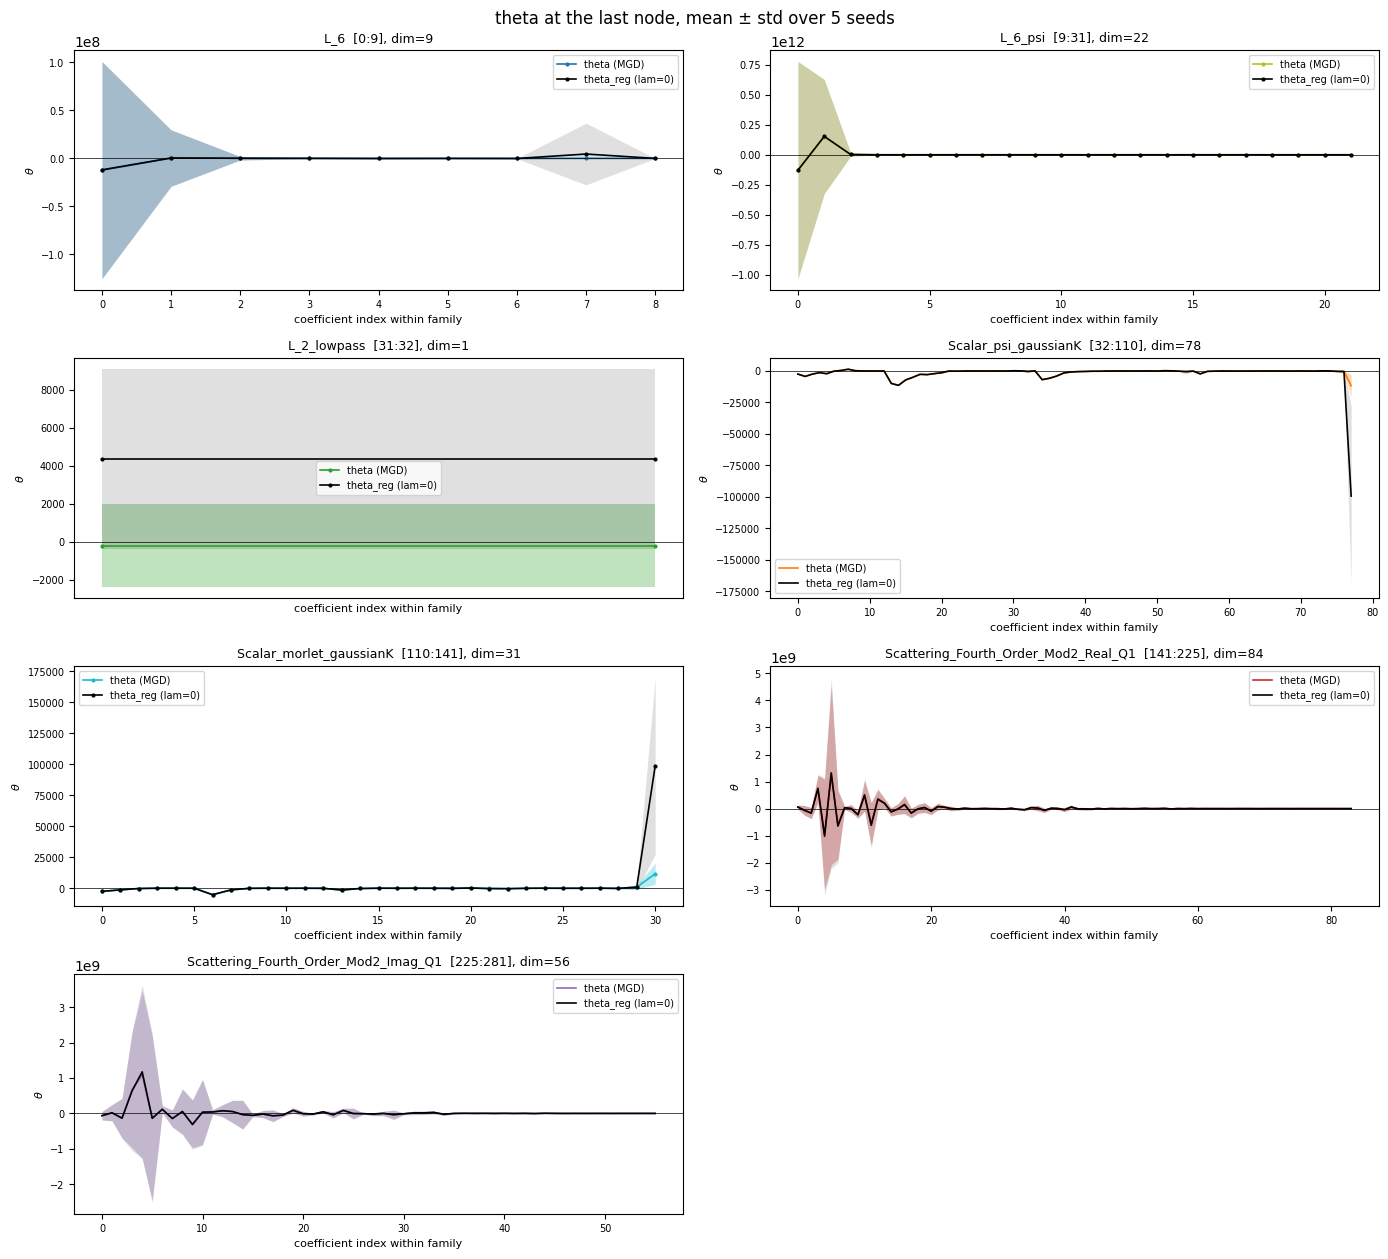

In [17]:
def _saved(kind, config):
    """saved_results/<kind>/<config>[.pt], or None if neither exists."""
    p = root / 'saved_results' / kind / config
    return next((q for q in (p.with_name(p.name + '.pt'), p) if q.exists()), None)

theta_mgd_by_seed, theta_reg0_by_seed = {}, {}
for key in seed_keys:
    path = _saved('lagrange_multipliers', config_by_seed[key])
    assert path is not None, f'{key}: no saved_results/lagrange_multipliers/{config_by_seed[key]}[.pt]'
    theta_t = torch.load(path, map_location='cpu')
    theta_mgd_by_seed[key] = theta_t[-1].double().numpy()
    print(f"{key}: theta_t {tuple(theta_t.shape)} -> last step")
    del theta_t
    if HAVE_REG:
        theta_reg0_by_seed[key] = torch.load(theta_path_by_seed[key], map_location='cpu',
                                             weights_only=False)['Theta_reg'][-1].double().numpy()

theta_sets = {'theta (MGD)': np.stack([theta_mgd_by_seed[k] for k in seed_keys])}   # (n_seeds, d)
if HAVE_REG:
    theta_sets[f'theta_reg (lam={LAM:g})'] = np.stack([theta_reg0_by_seed[k] for k in seed_keys])
assert len({v.shape for v in theta_sets.values()}) == 1, {k: v.shape for k, v in theta_sets.items()}
d_theta = theta_sets['theta (MGD)'].shape[1]

_pots0 = load_potentials_for_config(exp_dir_by_seed[seed_keys[0]], cfg_by_seed[seed_keys[0]], device)
family_ranges0 = {name: (a, a + w) for name, (a, w) in theta_column_map(_pots0, d_theta).items()}
del _pots0

# (line alpha, band alpha): MGD opaque, theta_reg the same color but faded
STYLE = {'theta (MGD)': (1.0, 0.30), 'theta_reg': (1.0, 0.12)}
n_cols = 2
n_rows = math.ceil(len(family_ranges0) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3.2 * n_rows), squeeze=False)
for i, (F, (a, b)) in enumerate(family_ranges0.items()):
    ax = axes[i // n_cols][i % n_cols]
    color = potential_colors.get(F, f'C{i}')
    idx = np.arange(b - a)
    for label, th in theta_sets.items():
        is_reg = label.startswith('theta_reg')
        la, fa = STYLE['theta_reg' if is_reg else label]
        c = 'k' if is_reg else color
        mean = th[:, a:b].mean(0)
        std = th[:, a:b].std(0, ddof=1) if th.shape[0] > 1 else np.zeros(b - a)
        # a 1-coefficient family would give a zero-width band: widen it to +-0.3 around 0
        xs, mean, std = (np.array([-0.3, 0.3]), mean.repeat(2), std.repeat(2)) if b - a == 1 else (idx, mean, std)
        ax.plot(xs, mean, color=c, alpha=la, lw=1.2, marker='.' if b - a < 40 else None, ms=4, label=label)
        ax.fill_between(xs, mean - std, mean + std, color=c, alpha=fa, lw=0)
    if b - a == 1:
        ax.set_xticks([])
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'{F}  [{a}:{b}], dim={b - a}', fontsize=9)
    ax.set_xlabel('coefficient index within family', fontsize=8)
    ax.set_ylabel(r'$\theta$', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
for j in range(len(family_ranges0), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')
fig.suptitle(f'theta at the last node, mean ± std over {len(seed_keys)} seeds'
             + ('' if HAVE_REG else '  (no theta_reg: LAM unset or not solved)'))
fig.tight_layout(); plt.show()

## Load Theta_reg (final node) and the fitted potentials, per seed

`Theta_reg[-1]` = the regularised θ at the last node of the grid (the two_phase grid is the same for every seed). `theta_t`/MGD is never used.

The fitted potentials are fitted on `x1`, the same for every seed, so they should agree across seeds. This is **checked**, not assumed: φ of each seed's potentials on the first `N_CHECK` signals is compared with the reference seed's. If they all agree, one `phi_X` is shared. Otherwise each seed gets its own `phi_X` (the rest of the notebook works either way).

In [13]:
assert HAVE_REG, 'set LAM to a value solved for every seed (listed in the config cell)'
N_CHECK = 200

theta_by_seed, potentials_by_seed = {}, {}
for key in seed_keys:
    sol = torch.load(theta_path_by_seed[key], map_location='cpu', weights_only=False)
    assert sol['config'] == config_by_seed[key]
    theta_by_seed[key] = sol['Theta_reg'][-1].double().numpy()
    potentials_by_seed[key] = load_potentials_for_config(exp_dir_by_seed[key], cfg_by_seed[key], device)
    print(f"{key}: Theta_reg {tuple(sol['Theta_reg'].shape)}, lam={sol['lam']:g}, residual {sol['residual']:.2e}, "
          f"last node t = {float(sol['t_reg'][-1]):.8f}")

widths = {k: v.shape[0] for k, v in theta_by_seed.items()}
assert len(set(widths.values())) == 1, f'Theta_reg widths differ across seeds: {widths}'
reg_all_np = np.stack([theta_by_seed[k] for k in seed_keys])    # (n_seeds, n_features)
n_seeds, n_features = reg_all_np.shape
theta_reg_mean = reg_all_np.mean(0)
theta_reg_std = reg_all_np.std(0, ddof=1) if n_seeds > 1 else np.full(n_features, np.nan)
print(f"reg_all: {reg_all_np.shape} ({n_seeds} seeds, {n_features} features)")

REFERENCE_SEED = seed_keys[0]
potentials_ref = potentials_by_seed[REFERENCE_SEED]
col_map = theta_column_map(potentials_ref, n_features)    # raises if the widths do not add up to n_features
family_ranges = {name: (a, a + d) for name, (a, d) in col_map.items()}
for name, (a, b) in family_ranges.items():
    print(f"  {name:45s} [{a:4d}:{b:<4d}]  dim={b - a}")

x_check = x1[:N_CHECK]
phi_check_ref = compute_phi_X(potentials_ref, x_check).double()
phi_diff = {k: (compute_phi_X(potentials_by_seed[k], x_check).double() - phi_check_ref).abs().max().item()
            for k in seed_keys[1:]}
PHI_SHARED = all(d == 0 for d in phi_diff.values())
print(f"max |phi_seed - phi_{REFERENCE_SEED}| on {N_CHECK} signals: {phi_diff} -> "
      f"{'one phi_X shared by all seeds' if PHI_SHARED else 'fitted potentials differ: phi_X computed per seed'}")

[deduplicate_filters] filters_Q: 25 -> 22 channels for channel-list potentials (dropped duplicates [21, 22, 23], tol=1e-08)
seed900: Theta_reg (59998, 281), lam=0, residual 9.19e-15, last node t = 0.99995000
[deduplicate_filters] filters_Q: 25 -> 22 channels for channel-list potentials (dropped duplicates [21, 22, 23], tol=1e-08)
seed901: Theta_reg (59998, 281), lam=0, residual 9.41e-15, last node t = 0.99995000
[deduplicate_filters] filters_Q: 25 -> 22 channels for channel-list potentials (dropped duplicates [21, 22, 23], tol=1e-08)
seed902: Theta_reg (59998, 281), lam=0, residual 8.18e-15, last node t = 0.99995000
[deduplicate_filters] filters_Q: 25 -> 22 channels for channel-list potentials (dropped duplicates [21, 22, 23], tol=1e-08)
seed903: Theta_reg (59998, 281), lam=0, residual 9.37e-15, last node t = 0.99995000
[deduplicate_filters] filters_Q: 25 -> 22 channels for channel-list potentials (dropped duplicates [21, 22, 23], tol=1e-08)
seed904: Theta_reg (59998, 281), lam=0, resi

## Whole-dataset rare/typical split

Method from `extract_samples.ipynb`: a signal is **rare** if its extremeness, $\max_t |x(t+1)-x(t)|$ (max absolute lag-1 increment), exceeds a percentile of that quantity over the dataset. It is applied to `x1`: the wavelet-decomposed **and normalized** signals that `phi_X` is computed on. So the labels line up with `phi_X`, and the cutoff is in the same units as the model samples (section 6).

`normalize` (`codes/utils.py`) is **global**: one scalar mean and one scalar std for the whole tensor, not per sample. A positive rescaling preserves the ranking, so the split should match one on un-normalized `Data[:n1]`; only the cutoff value changes, by the factor `Data[:n1].std()`. The cell checks both.

In [14]:
def compute_acceleration(Data):
    """a(t) = Data(t+1) - Data(t), lag-1 velocity increment."""
    return Data[..., 1:] - Data[..., :-1]

def extract_rare_typical(Data, criterion='percentile', std_threshold=40,
                          sustained_sigma=10, min_exceedances=3, percentile=95):
    accel = compute_acceleration(Data)
    accel_std = accel.flatten().std(unbiased=True).item()
    B = accel.shape[0]
    reduce_dims = tuple(range(1, accel.ndim))
    per_traj_max_abs_accel = accel.abs().amax(dim=reduce_dims)

    if criterion == 'max_sigma':
        is_rare = per_traj_max_abs_accel > std_threshold * accel_std
        info = dict(accel_std=accel_std, threshold=std_threshold * accel_std)
    elif criterion == 'sustained_sigma':
        exceed_mask = accel.abs() > sustained_sigma * accel_std
        per_traj_exceed_count = exceed_mask.reshape(B, -1).sum(dim=1)
        is_rare = per_traj_exceed_count >= min_exceedances
        info = dict(accel_std=accel_std, threshold=sustained_sigma * accel_std,
                    min_exceedances=min_exceedances, exceed_counts=per_traj_exceed_count)
    elif criterion == 'percentile':
        cutoff = np.percentile(per_traj_max_abs_accel.cpu().numpy(), percentile)
        is_rare = per_traj_max_abs_accel > cutoff
        info = dict(accel_std=accel_std, percentile=percentile, cutoff=cutoff)
    else:
        raise ValueError(f"unknown criterion '{criterion}'")

    idx_rare = torch.nonzero(is_rare).flatten().tolist()
    idx_typical = torch.nonzero(~is_rare).flatten().tolist()
    return idx_typical, idx_rare, info

idx_typical, idx_rare, info_split = extract_rare_typical(x1, criterion='percentile', percentile=95)
category_indices = {'typical': idx_typical, 'rare': idx_rare}
category_colors = {'typical': 'tab:blue', 'rare': 'tab:red'}
cutoff_p95 = info_split['cutoff']   # x1 (normalized) units
print(f"Whole dataset (n1={n1}) split on x1: typical {len(idx_typical)}, rare {len(idx_rare)} | "
      f"cutoff (p{info_split['percentile']}) = {cutoff_p95:.4g} in x1 units")

# Previous split, on un-normalized Data[:n1] -- only to report what changed.
_, idx_rare_old, info_old = extract_rare_typical(Data[:n1], criterion='percentile', percentile=95)
print(f"Old split on Data[:n1]: rare {len(idx_rare_old)}, cutoff (p{info_old['percentile']}) = "
      f"{info_old['cutoff']:.4g} in Data units | overlap with new rare set: "
      f"{len(set(idx_rare) & set(idx_rare_old))}/{len(idx_rare)} | cutoff ratio old/new = "
      f"{info_old['cutoff'] / cutoff_p95:.4g} vs Data[:n1].std() = {Data[:n1].std().item():.4g}")

Whole dataset (n1=8500) split on x1: typical 8075, rare 425 | cutoff (p95) = 0.3128 in x1 units
Old split on Data[:n1]: rare 425, cutoff (p95) = 1.004 in Data units | overlap with new rare set: 425/425 | cutoff ratio old/new = 3.21 vs Data[:n1].std() = 3.21


## Per-family energy, split by category

Same `phi_X`/`family_energy`/`total_log_p_unnorm` as the pooled notebook, just indexed by `category_indices` afterward -- the underlying $\theta^\top\varphi(x)$ computation is identical, only the grouping changes.

**Sign convention** (checked in `sde_routines.py`: the sampler ascends $+\nabla_x\,\theta^\top\varphi$): $p_\theta(x)\propto\exp(+\theta^\top\varphi(x))$, so $\theta^\top\varphi(x)=\log p_\theta(x)+\log Z(\theta)$.
Every "log p contribution" below is $\theta_F^\top\varphi_F(x)$ in this convention: higher means more likely.

In [9]:
phi_X = compute_phi_X(potentials_ref, x1).detach().cpu().double().numpy()   # (n1, n_features)
assert phi_X.shape == (n1, n_features), phi_X.shape
phi_by_seed = {k: phi_X if (PHI_SHARED or k == REFERENCE_SEED)
               else compute_phi_X(potentials_by_seed[k], x1).detach().cpu().double().numpy()
               for k in seed_keys}

ranges_with_total = {**family_ranges, 'TOTAL': (0, n_features)}
# C[F]: (n_seeds, n1) -- per-seed, per-signal log p contribution (nats) of family F
C = {F: np.stack([phi_by_seed[k][:, a:b] @ reg_all_np[s, a:b] for s, k in enumerate(seed_keys)])
     for F, (a, b) in ranges_with_total.items()}
# Seed-averaged contribution; with a shared phi_X this is exactly theta_reg_mean . phi(x)
C_bar = {F: C[F].mean(0) for F in C}
family_energy = {F: C_bar[F] for F in family_ranges}
total_log_p_unnorm = C_bar['TOTAL']

comparison = []
for category, idx in category_indices.items():
    for name in ranges_with_total:
        sample_totals = C_bar[name][idx]
        comparison.append({
            'category': category, 'family': name,
            'mean_total': sample_totals.mean(), 'std_total': sample_totals.std(ddof=1),
        })
comparison_df = pd.DataFrame(comparison)
print('seed-averaged theta; std_total = spread across signals')
display(comparison_df.pivot(index='family', columns='category', values=['mean_total', 'std_total']))

seed-averaged theta; std_total = spread across signals


mean_total           std_total         
category                                   rare   typical      rare  typical
family                                                                      
L_2_lowpass                            3.51e+03  3.57e+03  5.01e+03 5.04e+03
L_6                                    2.88e+04  1.93e+04  1.09e+05 1.16e+05
L_6_psi                               -2.83e+04 -1.89e+04  1.07e+05 1.13e+05
Scalar_morlet_gaussianK                 2.1e+05  2.19e+05  7.71e+05 7.77e+05
Scalar_psi_gaussianK                  -2.14e+05 -2.23e+05  7.77e+05 7.83e+05
Scattering_Fourth_Order_Mod2_Imag_Q1       20.1     0.509       227     27.2
Scattering_Fourth_Order_Mod2_Real_Q1       -435      -278  1.87e+03      802
TOTAL                                      -408      -303  1.59e+03 1.35e+03

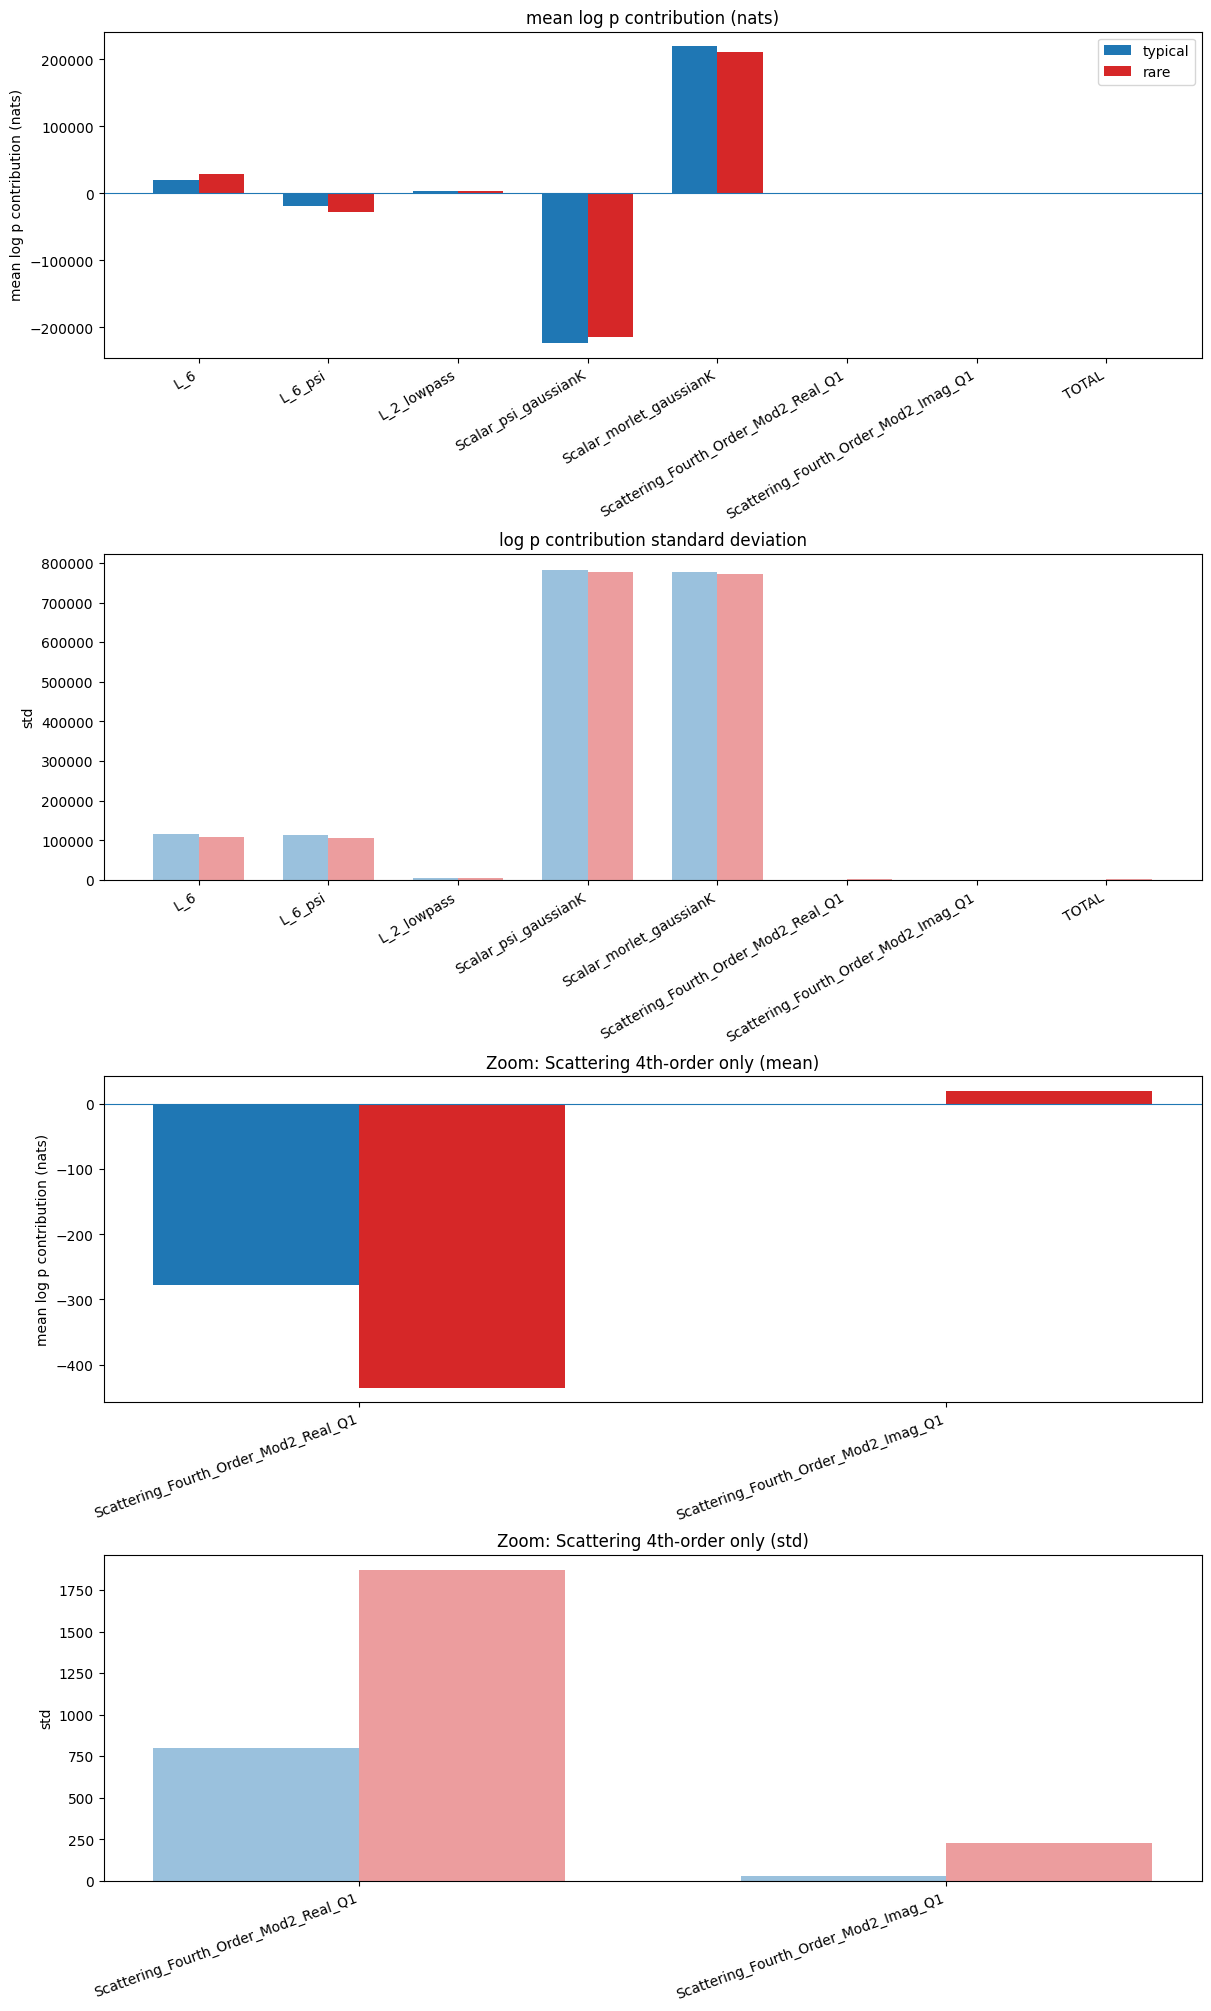

In [10]:
from matplotlib.colors import to_rgba

categories = list(category_indices.keys())
family_names = list(ranges_with_total.keys())   # all families + TOTAL
stats = comparison_df.set_index(['category', 'family'])
means = {c: stats.loc[c].loc[family_names, 'mean_total'].to_numpy() for c in categories}
stds = {c: stats.loc[c].loc[family_names, 'std_total'].to_numpy() for c in categories}
x = np.arange(len(family_names))
width = 0.35

# Scattering-4 (REAL_KEY/IMAG_KEY) bars, zoomed -- their scale is dwarfed by L_6 etc.
# in the full-range panels, so pull just these two out for a readable y-range.
scatter4_families = [REAL_KEY, IMAG_KEY]
zoom_idx = [family_names.index(name) for name in scatter4_families]
x_zoom = np.arange(len(scatter4_families))

fig, (ax_mean, ax_std, ax_mean_zoom, ax_std_zoom) = plt.subplots(4, 1, figsize=(12, 20), constrained_layout=True)
for i, category in enumerate(categories):
    offset = -width / 2 if i == 0 else width / 2
    color = category_colors[category]
    ax_mean.bar(x + offset, means[category], width, label=category, color=color)
    ax_std.bar(x + offset, stds[category], width, label=category, color=to_rgba(color, alpha=0.45))
    ax_mean_zoom.bar(x_zoom + offset, means[category][zoom_idx], width, label=category, color=color)
    ax_std_zoom.bar(x_zoom + offset, stds[category][zoom_idx], width, label=category,
                    color=to_rgba(color, alpha=0.45))

for ax in (ax_mean, ax_mean_zoom):
    ax.axhline(0, linewidth=0.8)
    ax.set_ylabel("mean log p contribution (nats)")
for ax in (ax_std, ax_std_zoom):
    ax.set_ylabel("std")
for ax in (ax_mean, ax_std):
    ax.set_xticks(x)
    ax.set_xticklabels(family_names, rotation=30, ha="right")
for ax in (ax_mean_zoom, ax_std_zoom):
    ax.set_xticks(x_zoom)
    ax.set_xticklabels(scatter4_families, rotation=20, ha="right")
ax_mean.set_title("mean log p contribution (nats)")
ax_std.set_title("log p contribution standard deviation")
ax_mean_zoom.set_title("Zoom: Scattering 4th-order only (mean)")
ax_std_zoom.set_title("Zoom: Scattering 4th-order only (std)")
ax_mean.legend()
plt.show()

## log p, typical vs rare

$\theta^\top\varphi(x)$ = $\log p_\theta(x)$ up to the additive constant $-\log Z(\theta)$ -- the SAME constant for both categories (same $\theta$), so shape and the gap between them are exact; only the absolute axis position is unknown.

typical: gumbel_r: loc=-995.2, scale=2219, loglik=-7.281e+04, KS D=0.316 | gumbel_l: loc=466.9, scale=3971, loglik=-7.656e+04, KS D=0.429  -> best: gumbel_r
rare: gumbel_r: loc=-1186, scale=1876, loglik=-3805, KS D=0.231 | gumbel_l: loc=464.3, scale=2327, loglik=-3879, KS D=0.257  -> best: gumbel_r


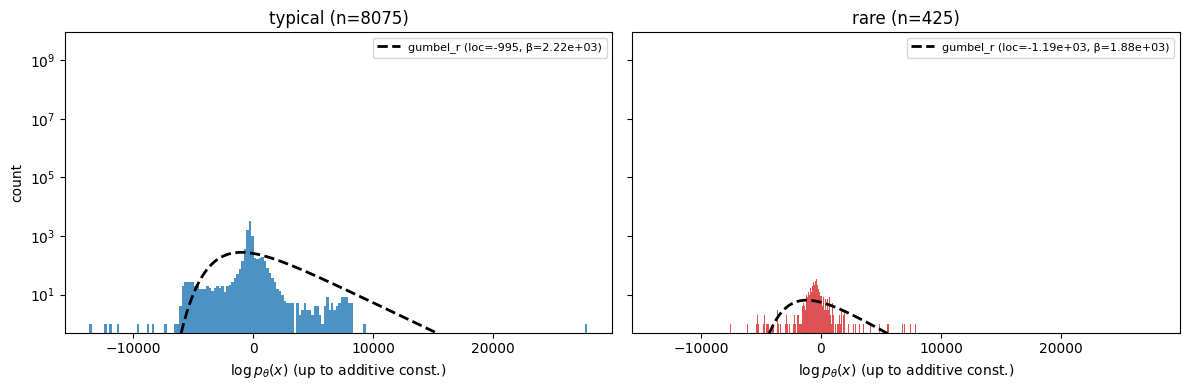

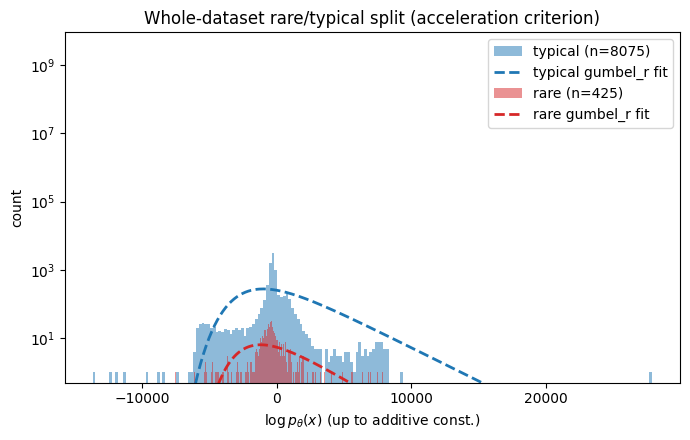

mean log p_theta, up to the same additive constant: typical = -302.6, rare = -407.5  ->  rare < typical: True


In [20]:
from scipy import stats

def _to_np(x):
    return x.detach().cpu().numpy().astype(float) if hasattr(x, 'detach') else np.asarray(x, dtype=float)

logp_by_category = {category: _to_np(total_log_p_unnorm[idx]) for category, idx in category_indices.items()}

# --- Gumbel fit per category: try both orientations, keep the better one by log-likelihood ---
gumbel_fits = {}
for category, x in logp_by_category.items():
    candidates = {}
    for name, dist in (('gumbel_r', stats.gumbel_r), ('gumbel_l', stats.gumbel_l)):
        loc, scale = dist.fit(x)
        candidates[name] = dict(dist=dist, loc=loc, scale=scale,
                                loglik=dist.logpdf(x, loc, scale).sum(),
                                ks=stats.kstest(x, dist.cdf, args=(loc, scale)).statistic)
    best = max(candidates, key=lambda k: candidates[k]['loglik'])
    gumbel_fits[category] = {**candidates[best], 'kind': best}
    print(f"{category}: " + " | ".join(
        f"{k}: loc={c['loc']:.4g}, scale={c['scale']:.4g}, loglik={c['loglik']:.4g}, KS D={c['ks']:.3g}"
        for k, c in candidates.items()) + f"  -> best: {best}")

def _overlay_gumbel(ax, x, edges, fit, color, label=None):
    grid = np.linspace(edges[0], edges[-1], 400)
    bin_width = edges[1] - edges[0]
    ax.plot(grid, fit['dist'].pdf(grid, fit['loc'], fit['scale']) * len(x) * bin_width,
            color=color, lw=2, ls='--', label=label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (category, logp) in zip(axes, logp_by_category.items()):
    color = category_colors.get(category, 'tab:gray')
    _, edges, _ = ax.hist(logp, bins=200, color=color, alpha=0.8)
    fit = gumbel_fits[category]
    _overlay_gumbel(ax, logp, edges, fit, 'k',
                    label=f"{fit['kind']} (loc={fit['loc']:.3g}, β={fit['scale']:.3g})")
    ax.set_title(f'{category} (n={len(logp)})')
    ax.set_xlabel(r'$\log p_\theta(x)$ (up to additive const.)')
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.5)   # keep the pdf's far tail from stretching the log axis
    ax.legend(fontsize=8)
axes[0].set_ylabel('count')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for category, logp in logp_by_category.items():
    color = category_colors.get(category, 'tab:gray')
    _, edges, _ = ax.hist(logp, bins=200, color=color, alpha=0.5, label=f'{category} (n={len(logp)})')
    _overlay_gumbel(ax, logp, edges, gumbel_fits[category], color,
                    label=f"{category} {gumbel_fits[category]['kind']} fit")
ax.set_xlabel(r'$\log p_\theta(x)$ (up to additive const.)')
ax.set_ylabel('count')
ax.set_yscale('log')
ax.set_ylim(bottom=0.5)
ax.legend()
ax.set_title('Whole-dataset rare/typical split (acceleration criterion)')
fig.tight_layout()
plt.show()

mean_logp = {category: logp.mean() for category, logp in logp_by_category.items()}
print("mean log p_theta, up to the same additive constant: "
      + ", ".join(f"{category} = {m:.4g}" for category, m in mean_logp.items())
      + f"  ->  rare < typical: {mean_logp['rare'] < mean_logp['typical']}")

The printed line above says whether rare events sit at lower $\log p_\theta$ (seed-averaged θ) than typical ones for these runs. The gap between the two means is exact, because $\log Z(\theta)$ is the same for both.

## Florentin's plot 

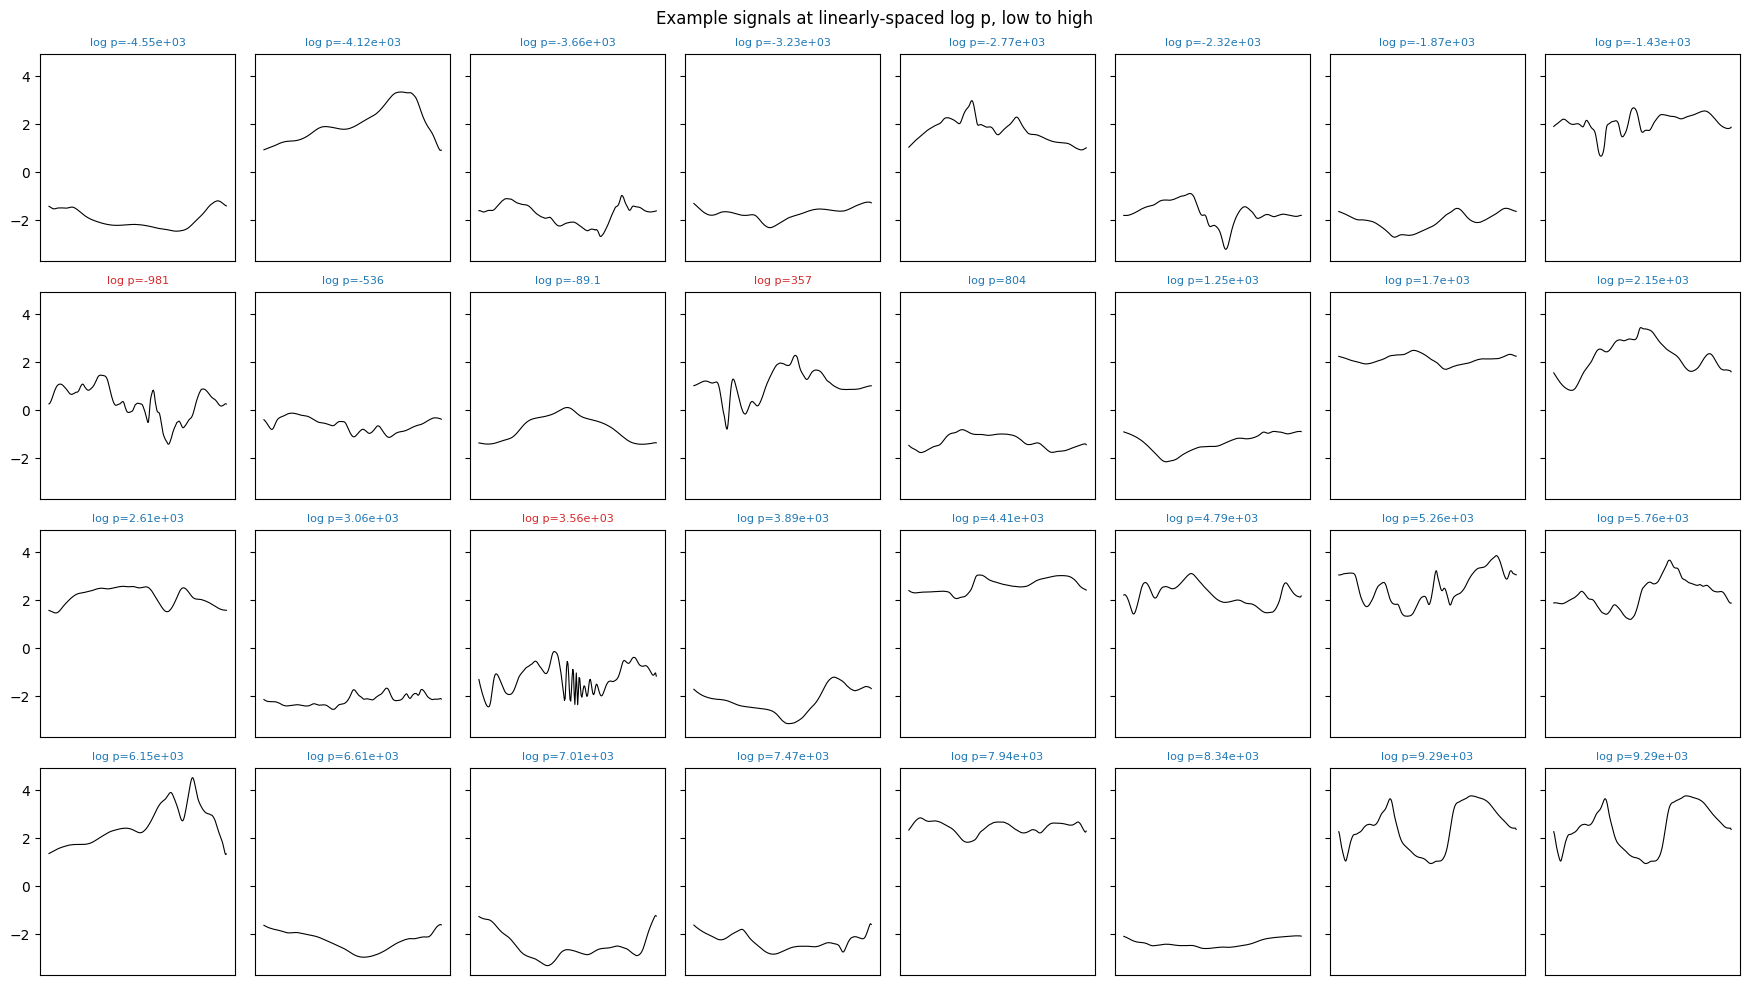

In [26]:
n_examples = 32 # any number; wraps at 8 per row
n_cols = 8
n_rows = math.ceil(n_examples / n_cols)

logp_targets = np.linspace(total_log_p_unnorm.min()//3, total_log_p_unnorm.max()//3, n_examples)
example_idx = [int(np.argmin(np.abs(total_log_p_unnorm - t))) for t in logp_targets]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.5 * n_rows), sharey=True, squeeze=False)
for i, idx in enumerate(example_idx):
    ax = axes[i // n_cols][i % n_cols]
    ax.plot(x1[idx, 0].cpu().numpy(), lw=0.8, color='black')
    label_color = category_colors['rare'] if idx in set(idx_rare) else category_colors['typical']
    ax.set_title(f'log p={total_log_p_unnorm[idx]:.3g}', fontsize=8, color=label_color)
    ax.set_xticks([])
for j in range(n_examples, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')
fig.suptitle('Example signals at linearly-spaced log p, low to high')
fig.tight_layout()
plt.show()

## 1. Per-seed family contributions with error bars

For each seed $s$, `C[F][s, i]` $=\theta_{s,F}^\top\varphi_F(x_i)$ (log p contribution, nats), and `D[s, F]` = mean of `C[F][s]` over rare minus mean over typical. The table gives the mean/std of `D` across seeds, plus a bootstrap SE over the `len(idx_rare)` rare signals (resampled with the seed-averaged `C`; typical held fixed). The counts are printed below.

sum(family D) - TOTAL D = 1.105e-09  (should be ~0)
D over 5 seeds; bootstrap: 1000 resamples of the 425 rare signals (typical, n=8075, held fixed)


,family,mean_D,std_D_across_seeds,bootstrap_SE_rare
0,L_6,9.46e+03,8.9e+04,5.19e+03
1,L_6_psi,-9.46e+03,8.91e+04,5.09e+03
2,L_2_lowpass,-60.3,65.9,235
3,Scalar_psi_gaussianK,8.94e+03,7.41e+03,3.67e+04
4,Scalar_morlet_gaussianK,-8.85e+03,7.15e+03,3.64e+04
5,Scattering_Fourth_Order_Mod2_Real_Q1,-158,396,87.4
6,Scattering_Fourth_Order_Mod2_Imag_Q1,19.6,54.9,10.4
7,TOTAL,-105,513,75.7


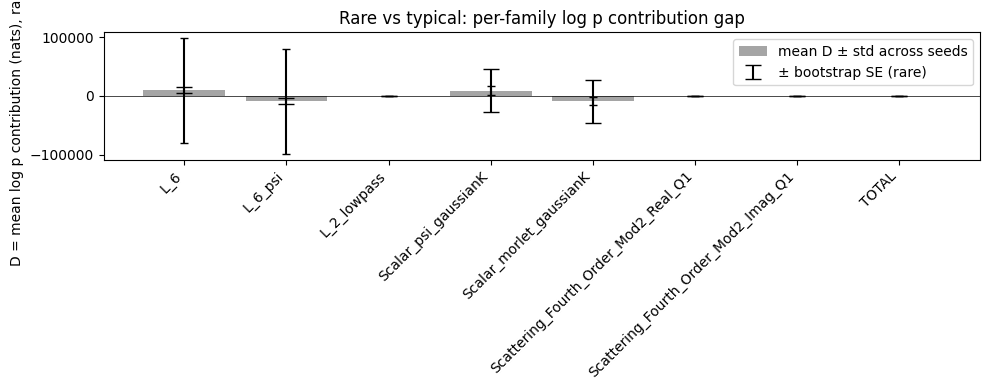

In [14]:
family_names_all = list(ranges_with_total.keys())  # all families + TOTAL
# C[F] (n_seeds, n1) and C_bar[F] (n1,) are built in the per-family energy cell above

D = np.stack([C[F][:, idx_rare].mean(axis=1) - C[F][:, idx_typical].mean(axis=1)
              for F in family_names_all], axis=1)  # (n_seeds, n_families+1)
D_mean = D.mean(axis=0)
D_std = D.std(axis=0, ddof=1) if n_seeds > 1 else np.full(D.shape[1], np.nan)

# sanity check: C[TOTAL] = sum_F C[F] exactly (linear), so D[TOTAL] should equal sum_F D[F]
total_i = family_names_all.index('TOTAL')
family_sum = sum(D_mean[i] for i, F in enumerate(family_names_all) if F != 'TOTAL')
print(f"sum(family D) - TOTAL D = {family_sum - D_mean[total_i]:.3e}  (should be ~0)")

# Bootstrap SE over the rare signals only (typical held fixed), using the
# seed-averaged C_bar.
rng = np.random.default_rng(0)  # assumption: fixed seed for reproducibility, not specified
n_boot = 1000
idx_rare_arr = np.array(idx_rare)
typical_mean = {F: C_bar[F][idx_typical].mean() for F in family_names_all}
boot_D = np.empty((n_boot, len(family_names_all)))
for b in range(n_boot):
    resample = rng.choice(idx_rare_arr, size=len(idx_rare_arr), replace=True)
    boot_D[b] = [C_bar[F][resample].mean() - typical_mean[F] for F in family_names_all]
boot_se = boot_D.std(axis=0, ddof=1)
print(f"D over {n_seeds} seeds; bootstrap: {n_boot} resamples of the {len(idx_rare)} rare signals "
      f"(typical, n={len(idx_typical)}, held fixed)")

table1 = pd.DataFrame({'family': family_names_all, 'mean_D': D_mean,
                        'std_D_across_seeds': D_std, 'bootstrap_SE_rare': boot_se})
display(table1)

fig, ax = plt.subplots(figsize=(10, 4))
xpos = np.arange(len(family_names_all))
ax.bar(xpos, D_mean, yerr=D_std, capsize=3, color='tab:gray', alpha=0.7,
       label='mean D ± std across seeds')
ax.errorbar(xpos, D_mean, yerr=boot_se, fmt='none', ecolor='black', capsize=6, lw=1.5,
            label='± bootstrap SE (rare)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(xpos); ax.set_xticklabels(family_names_all, rotation=45, ha='right')
ax.set_ylabel('D = mean log p contribution (nats), rare - typical')
ax.set_title('Rare vs typical: per-family log p contribution gap')
ax.legend()
fig.tight_layout()
plt.show()

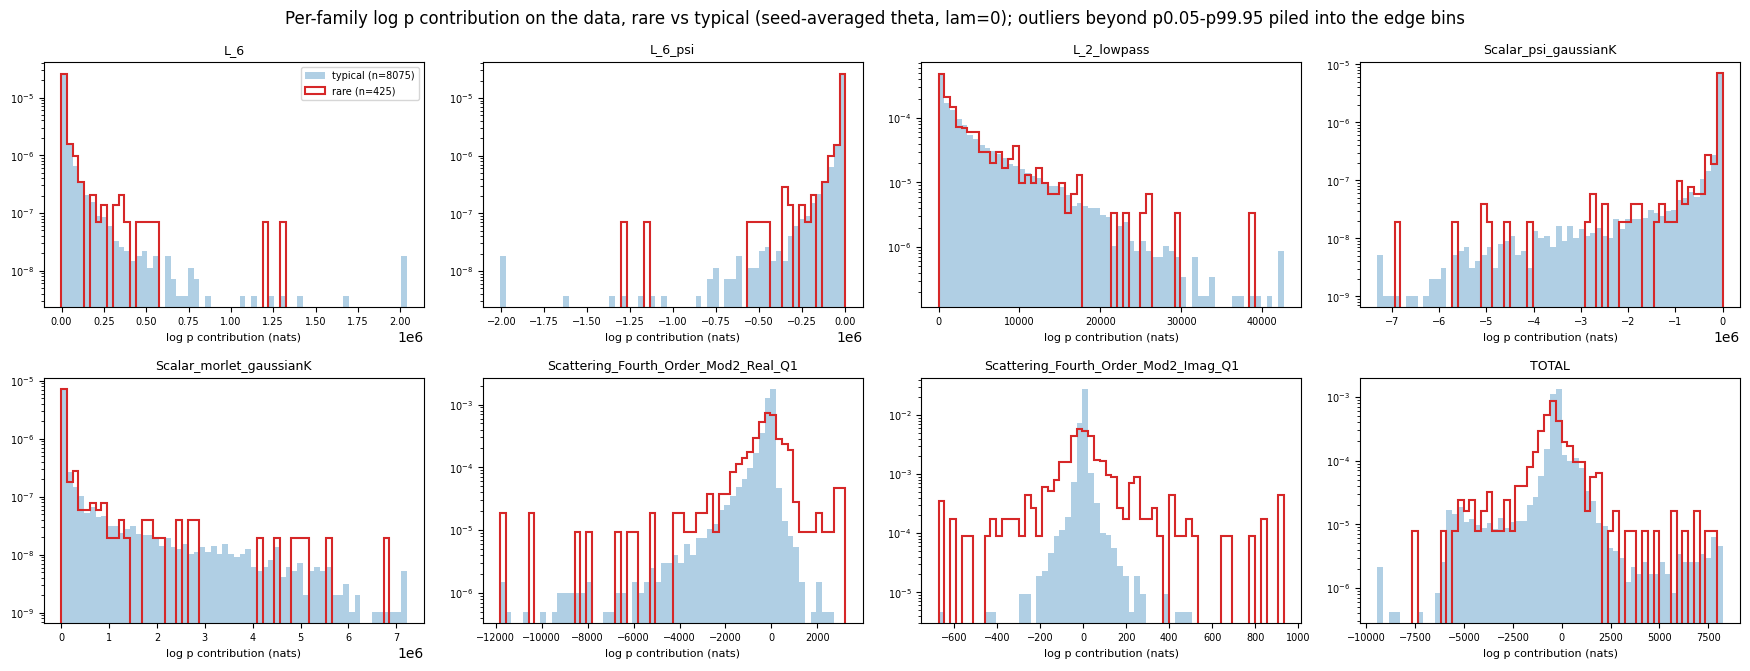

mean                std           \
category                                  rare   typical     rare  typical   
family                                                                       
L_2_lowpass                           3.51e+03  3.57e+03 5.01e+03 5.04e+03   
L_6                                   2.88e+04  1.93e+04 1.09e+05 1.16e+05   
L_6_psi                              -2.83e+04 -1.89e+04 1.07e+05 1.13e+05   
Scalar_morlet_gaussianK                2.1e+05  2.19e+05 7.71e+05 7.77e+05   
Scalar_psi_gaussianK                 -2.14e+05 -2.23e+05 7.77e+05 7.83e+05   
Scattering_Fourth_Order_Mod2_Imag_Q1      20.1     0.509      227     27.2   
Scattering_Fourth_Order_Mod2_Real_Q1      -435      -278 1.87e+03      802   
TOTAL                                     -408      -303 1.59e+03 1.35e+03   

                                      skew         excess kurtosis           \
category                              rare typical            rare  typical   
family                                                                        
L_2_lowpass                            2.7    2.79            9.94     12.8   
L_6                                    7.9    32.8            76.6 1.62e+03   
L_6_psi                               -7.9   -32.7            76.8 1.61e+03   
Scalar_morlet_gaussianK               5.31    5.03            31.3     29.3   
Scalar_psi_gaussianK                 -5.31   -5.04            31.3     29.5   
Scattering_Fourth_Order_Mod2_Imag_Q1  1.02  -0.581            10.7      140   
Scattering_Fourth_Order_Mod2_Real_Q1    -4   -8.31            32.2      119   
TOTAL                                0.833    1.05            8.31       39   

                                            p1                p99           
category                                  rare   typical     rare  typical  
family                                                                      
L_2_lowpass                               1.86      1.11 2.47e+04 2.28e+04  
L_6                                       -469       -23 4.89e+05 2.82e+05  
L_6_psi                              -4.82e+05 -2.75e+05      732    0.775  
Scalar_morlet_gaussianK              -1.24e+03 -1.03e+03 4.79e+06  4.4e+06  
Scalar_psi_gaussianK                 -4.82e+06 -4.42e+06      327     5.18  
Scattering_Fourth_Order_Mod2_Imag_Q1      -612     -69.6      935     74.3  
Scattering_Fourth_Order_Mod2_Real_Q1 -8.25e+03 -3.51e+03 3.22e+03      379  
TOTAL                                -5.24e+03 -5.43e+03  6.2e+03 4.83e+03

In [21]:
# Shape of each family's log p contribution C_F(x) = theta_F . phi_F(x) on the data (x1),
# seed-averaged theta, rare vs typical overlaid. density=True: the two categories have very
# different sizes (425 vs 8075), so compare shapes, not counts. Each panel has its own x-range
# (the Scattering families are orders of magnitude smaller than L_6).
from scipy import stats

fams = list(ranges_with_total.keys())            # 7 families + TOTAL
n_cols = 4
n_rows = math.ceil(len(fams) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.4 * n_rows), squeeze=False)

shape_rows = []
for i, F in enumerate(fams):
    ax = axes[i // n_cols][i % n_cols]
    vals = C_bar[F]
    lo, hi = np.percentile(vals, [0.05, 99.95])   # clip extreme outliers from the bin range only
    edges = np.linspace(lo, hi, 61)
    for cat, idx in category_indices.items():
        v = vals[idx]
        ax.hist(np.clip(v, lo, hi), bins=edges, density=True, histtype='stepfilled' if cat == 'typical' else 'step',
                color=category_colors[cat], alpha=0.35 if cat == 'typical' else 1.0, lw=1.5,
                label=f'{cat} (n={len(v)})')
        shape_rows.append({'family': F, 'category': cat, 'mean': v.mean(), 'std': v.std(ddof=1),
                           'skew': stats.skew(v), 'excess kurtosis': stats.kurtosis(v),
                           'p1': np.percentile(v, 1), 'p99': np.percentile(v, 99)})
    ax.set_yscale('log')
    ax.set_title(F, fontsize=9)
    ax.set_xlabel('log p contribution (nats)', fontsize=8)
    ax.tick_params(labelsize=7)
axes[0][0].legend(fontsize=7)
for j in range(len(fams), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')
fig.suptitle(f'Per-family log p contribution on the data, rare vs typical (seed-averaged theta, lam={LAM:g}); '
             'outliers beyond p0.05-p99.95 piled into the edge bins')
fig.tight_layout(); plt.show()

shape_df = pd.DataFrame(shape_rows).set_index(['family', 'category'])
display(shape_df.unstack('category'))

## 2. Robustness to the rare/typical threshold

Repeat the seed-mean `D` (no bootstrap) for each percentile in `percentiles`, split on `x1` as above. The number of rare signals at each percentile is printed below the table.

In [15]:
percentiles = [95, 99, 99.5]
table2, n_rare_p = {}, {}
for p in percentiles:
    idx_typ_p, idx_rare_p, _ = extract_rare_typical(x1, criterion='percentile', percentile=p)
    n_rare_p[f'p{p}'] = len(idx_rare_p)
    table2[f'p{p}'] = [C[F][:, idx_rare_p].mean(axis=1).mean() - C[F][:, idx_typ_p].mean(axis=1).mean()
                        for F in family_names_all]
table2_df = pd.DataFrame(table2, index=family_names_all)
display(table2_df)
print('n_rare per percentile:', n_rare_p)

,p95,p99,p99.5
L_6,9.46e+03,-2.49e+03,-1.38e+04
L_6_psi,-9.46e+03,2.4e+03,1.37e+04
L_2_lowpass,-60.3,-386,-1.12e+03
Scalar_psi_gaussianK,8.94e+03,9.04e+04,1.95e+05
Scalar_morlet_gaussianK,-8.85e+03,-8.97e+04,-1.94e+05
Scattering_Fourth_Order_Mod2_Real_Q1,-158,-319,-598
Scattering_Fourth_Order_Mod2_Imag_Q1,19.6,89.2,140
TOTAL,-105,-35.1,-315


n_rare per percentile: {'p95': 425, 'p99': 85, 'p99.5': 43}


## 3. Continuous version (no split)

Extremeness `e_i` = max over time of |lag-1 increment| of `x1[i]` (same definition and units as the split). Per family: centered log p contribution vs `e_i` (log x-axis), with the `idx_rare` signals highlighted. Table: Spearman rank correlation per family.

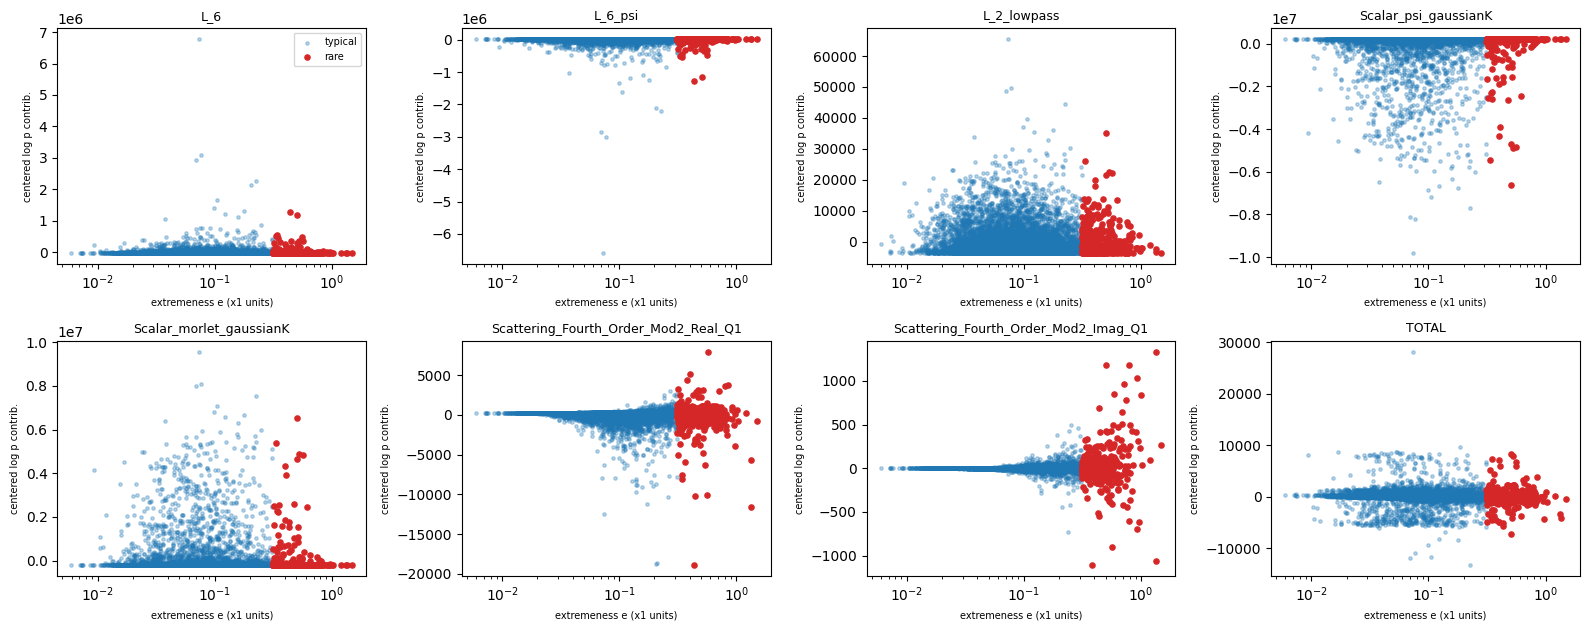

,family,spearman_rho
0,L_6,0.131
1,L_6_psi,-0.151
2,L_2_lowpass,-0.000756
3,Scalar_psi_gaussianK,-0.0754
4,Scalar_morlet_gaussianK,0.0662
5,Scattering_Fourth_Order_Mod2_Real_Q1,-0.106
6,Scattering_Fourth_Order_Mod2_Imag_Q1,0.0176
7,TOTAL,-0.242


In [16]:
accel = compute_acceleration(x1)  # (n1, 1, M-1)
e = accel.abs().amax(dim=(1, 2)).cpu().numpy()  # (n1,) extremeness

n_cols = 4
n_rows = math.ceil(len(family_names_all) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows), squeeze=False)
mask_rare = np.zeros(n1, dtype=bool)
mask_rare[idx_rare] = True

spearman_rows = []
for i, F in enumerate(family_names_all):
    ax = axes[i // n_cols][i % n_cols]
    y = C_bar[F] - C_bar[F].mean()
    ax.scatter(e[~mask_rare], y[~mask_rare], s=6, alpha=0.3, color=category_colors['typical'], label='typical')
    ax.scatter(e[mask_rare], y[mask_rare], s=14, color=category_colors['rare'], label='rare')
    ax.set_xscale('log')
    ax.set_title(F, fontsize=9)
    ax.set_xlabel('extremeness e (x1 units)', fontsize=7)
    ax.set_ylabel('centered log p contrib.', fontsize=7)
    # Spearman = Pearson correlation of ranks (avoids a scipy import)
    rho = np.corrcoef(pd.Series(e).rank(), pd.Series(C_bar[F]).rank())[0, 1]
    spearman_rows.append({'family': F, 'spearman_rho': rho})
axes[0][0].legend(fontsize=7)
for j in range(len(family_names_all), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')
fig.tight_layout()
plt.show()

display(pd.DataFrame(spearman_rows))

## 4. Compensation between families

Correlation matrix of the families' log p contributions (seed-averaged $\theta$) across all `n1` signals. Then the sign-aware variance decomposition $\sum_{F\neq G}\mathrm{Cov}(C_F,C_G)=\mathrm{Var}(\mathrm{TOTAL})-\sum_F\mathrm{Var}(C_F)$: positive means the cross-family covariances **add** variance, negative means they **remove** it (compensation). The largest pairwise terms $2\,\mathrm{Cov}(C_F,C_G)$ are listed with their sign.

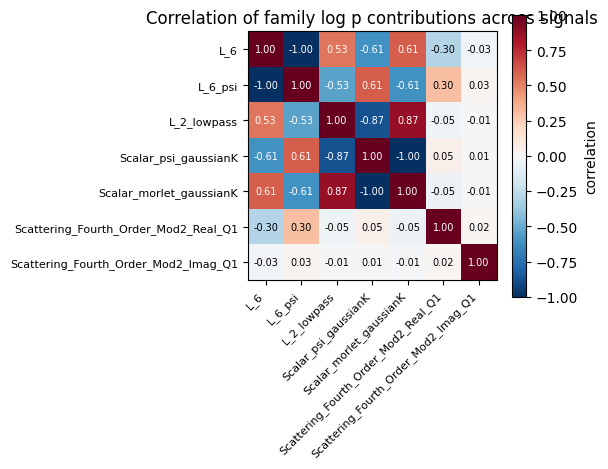

Var(TOTAL) = 1.855e+06
sum_F Var(C_F) = 1.242e+12
sum_(F!=G) Cov(C_F, C_G) = Var(TOTAL) - sum_F Var(C_F) = -1.242e+12  ->  cross-family covariance removes 100.0% of sum_F Var(C_F)
3 largest pairwise terms 2*Cov(C_F, C_G) by |value| (+ reinforces, - compensates):
  -1.216e+12   Scalar_psi_gaussianK & Scalar_morlet_gaussianK
  -1.1e+11   L_6 & Scalar_psi_gaussianK
  +1.088e+11   L_6 & Scalar_morlet_gaussianK


In [17]:
fam_only = list(family_ranges.keys())
C_mat = np.stack([C_bar[F] for F in fam_only], axis=0)  # (7, n1)
corr = np.corrcoef(C_mat)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(fam_only))); ax.set_xticklabels(fam_only, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(fam_only))); ax.set_yticklabels(fam_only, fontsize=8)
for i in range(len(fam_only)):
    for j in range(len(fam_only)):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr[i, j]) > 0.5 else 'black')
fig.colorbar(im, ax=ax, label='correlation')
ax.set_title('Correlation of family log p contributions across signals')
fig.tight_layout()
plt.show()

var_total = C_bar['TOTAL'].var(ddof=1)
var_sum_families = sum(C_bar[F].var(ddof=1) for F in fam_only)
cross_cov = var_total - var_sum_families   # = sum_{F != G} Cov(C_F, C_G)
print(f"Var(TOTAL) = {var_total:.4g}")
print(f"sum_F Var(C_F) = {var_sum_families:.4g}")
print(f"sum_(F!=G) Cov(C_F, C_G) = Var(TOTAL) - sum_F Var(C_F) = {cross_cov:.4g}  ->  cross-family covariance "
      f"{'adds' if cross_cov > 0 else 'removes'} {100 * abs(cross_cov) / var_sum_families:.1f}% of sum_F Var(C_F)")

cov_fam = np.cov(C_mat, ddof=1)
pair_terms = [(2 * cov_fam[i, j], fam_only[i], fam_only[j])
              for i in range(len(fam_only)) for j in range(i + 1, len(fam_only))]
print("3 largest pairwise terms 2*Cov(C_F, C_G) by |value| (+ reinforces, - compensates):")
for term, F, G in sorted(pair_terms, key=lambda t: -abs(t[0]))[:3]:
    print(f"  {term:+.4g}   {F} & {G}")

## 5. Residual variance: which families are irreplaceable?

With $p_\theta\propto e^{+\theta^\top\varphi}$, write $C_F(x)=\theta_F^\top\varphi_F(x)$, so $\log p_\theta=\sum_F C_F-\log Z(\theta)$. The raw variance $\mathrm{Var}[C_F]$ overstates a family's role when other families can reproduce part of $C_F$ (compensation, near-collinear features). We therefore measure the part they cannot reproduce:
$$R_F=\min_\beta\,\mathrm{Var}\big[C_F-\beta^\top\varphi_{\bar F}\big].$$

**Why this quantity.** For an exponential family, $\mathrm{KL}(p_\theta\|p_{\theta+\delta})=\tfrac12\,\delta^\top\Sigma\,\delta+O(|\delta|^3)$ with $\Sigma=\mathrm{Cov}_{p_\theta}[\varphi]$ (standard). Removing $F$ ($\delta_F=-\theta_F$) and optimally refitting the other couplings costs, to second order, $\tfrac12 R_F$ (a Schur complement of $\Sigma$). So $R_F$ measures the information lost by dropping $F$. Computed on the rare subset, it is the same statement for $p_\theta(x\mid x\in\text{rare})$.

We report three levels, $\mathrm{Var}[C_F]\ \ge\ R_F^{\rm fam}\ \ge\ R_F$, where $R_F^{\rm fam}$ only lets other families rescale ($\beta$ acting on the $C_G$, $G\neq F$), and $R_F$ allows a full refit on the other families' features (ridge, cross-fitted). For a pair, $\mathrm{Var}[C_F+C_G]$ upper-bounds the cost of removing both: if small, $F$ and $G$ are **redundant** (each can replace the other), not individually irrelevant.

**Caveats.** (i) Variances are computed on data, a proxy for the model covariance. (ii) The expansion is local: it underestimates the cost of confining terms whose removal breaks normalizability; for such terms (plausibly L_6) small variance does not mean irrelevance. (iii) Small $R_F$ means *replaceable*, not *physically meaningless*.

*Implementation.* Both $R_F^{\rm fam}$ (least squares) and $R_F$ (ridge) are 2-fold cross-fitted on the same random split of each set: fit on one half, take residuals on the other, swap, pool. Ridge regressors are standardized on the training fold, with penalty $n_{\rm train}\,\lambda\,|\beta|^2$ and one $\lambda$ chosen on `all` (printed below).

In [18]:
sets = {'all': np.arange(n1), 'typical': np.array(idx_typical), 'rare': np.array(idx_rare)}
rng = np.random.default_rng(0)   # assumption: random 2-fold split, fixed seed
folds = {name: np.array_split(rng.permutation(idx), 2) for name, idx in sets.items()}
C64 = {F: C[F].astype(np.float64) for F in fam_only}          # (n_seeds, n1), from the energy cell
# regressors: the other families' features, from each seed's own phi (all the same object if PHI_SHARED)
X_notF = {k: {F: np.delete(phi_by_seed[k], np.r_[a:b], axis=1) for F, (a, b) in family_ranges.items()}
          for k in (seed_keys if not PHI_SHARED else [REFERENCE_SEED])}
X_of = lambda s, F: X_notF[seed_keys[s] if not PHI_SHARED else REFERENCE_SEED][F]

def crossfit_resid_var(X, Y, fold_pair, lam):
    """2-fold cross-fitted residual variance of Y (n1, k) regressed on X (n1, p) with intercept,
    columns of X standardized on the training fold; lam=None -> least squares, else ridge with
    penalty n_train * lam * |beta|^2. fold_pair holds row indices into X/Y. Returns (k,)."""
    resid = []
    for tr, te in (fold_pair, fold_pair[::-1]):
        mu, sd = X[tr].mean(0), X[tr].std(0)
        sd[sd == 0] = 1.0
        Xtr, Xte = (X[tr] - mu) / sd, (X[te] - mu) / sd
        ybar = Y[tr].mean(0)
        pen = 0.0 if lam is None else len(tr) * lam
        beta = np.linalg.solve(Xtr.T @ Xtr + pen * np.eye(X.shape[1]), Xtr.T @ (Y[tr] - ybar))
        resid.append(Y[te] - ybar - Xte @ beta)
    return np.concatenate(resid).var(axis=0, ddof=1)

def r_feat(F, set_name, lam):
    """(n_seeds,) ridge residual variance of C_F on the other families' features."""
    if PHI_SHARED:   # one regression, every seed a column of Y
        return crossfit_resid_var(X_of(0, F), C64[F].T, folds[set_name], lam)
    return np.array([crossfit_resid_var(X_of(s, F), C64[F][s][:, None], folds[set_name], lam)[0]
                     for s in range(n_seeds)])

def var_raw(F, set_name):
    return C64[F][:, sets[set_name]].var(axis=1, ddof=1)       # (n_seeds,)

# Ridge lambda: one value for all families, minimizing mean_{F, seeds} R_feat/var_raw on 'all'.
lam_grid = np.logspace(-6, 0, 7)
lam_score = [np.mean([(r_feat(F, 'all', lam) / var_raw(F, 'all')).mean() for F in fam_only]) for lam in lam_grid]
lam_ridge = lam_grid[int(np.argmin(lam_score))]
print("mean R_feat/var_raw on 'all' per lambda: "
      + ", ".join(f"{lam:.0e}: {s:.4g}" for lam, s in zip(lam_grid, lam_score)))
print(f"ASSUMPTION: ridge lambda fixed at {lam_ridge:.0e} for every set/family"
      + ("  (WARNING: at the edge of the grid)" if lam_ridge in (lam_grid[0], lam_grid[-1]) else ""))

res = {}   # (set, F) -> per-seed arrays
for set_name in sets:
    for F in fam_only:
        others = [G for G in fam_only if G != F]
        r_fam = np.array([crossfit_resid_var(np.stack([C64[G][s] for G in others], axis=1),
                                             C64[F][s][:, None], folds[set_name], None)[0]
                          for s in range(n_seeds)])
        rf = r_feat(F, set_name, lam_ridge)
        v = var_raw(F, set_name)
        res[set_name, F] = {'var_raw': v, 'R_fam': r_fam, 'R_feat': rf, 'R_feat/var_raw': rf / v}

# Bootstrap over rare signals, seed-averaged C_bar and the reference seed's features, for
# R_feat/var_raw. Resampled within each fold, so a duplicated signal never sits in both halves.
rng = np.random.default_rng(0)
n_boot = 1000
f0, f1 = folds['rare']
boot_ratio = np.empty((n_boot, len(fam_only)))
for bi in range(n_boot):
    bfolds = (rng.choice(f0, len(f0)), rng.choice(f1, len(f1)))
    bidx = np.concatenate(bfolds)
    for j, F in enumerate(fam_only):
        y = C_bar[F].astype(np.float64)[:, None]
        boot_ratio[bi, j] = crossfit_resid_var(X_of(0, F), y, bfolds, lam_ridge)[0] / y[bidx].var(ddof=1)
rare_point = [crossfit_resid_var(X_of(0, F), C_bar[F].astype(np.float64)[:, None], folds['rare'], lam_ridge)[0]
              / C_bar[F][idx_rare].var(ddof=1) for F in fam_only]

sd = lambda a: a.std(ddof=1) if len(a) > 1 else np.nan
quantities = ['var_raw', 'R_fam', 'R_feat', 'R_feat/var_raw']
table_rv = pd.DataFrame({(set_name, q): [f"{res[set_name, F][q].mean():.3g} ± {sd(res[set_name, F][q]):.2g}"
                                         for F in fam_only]
                         for set_name in sets for q in quantities}, index=fam_only)
table_rv[('rare', 'R_feat/var_raw, mean theta ± boot SE')] = [
    f"{p:.3g} ± {se:.2g}" for p, se in zip(rare_point, boot_ratio.std(axis=0, ddof=1))]
print(f"mean ± std across {n_seeds} seeds; set sizes: " + ", ".join(f"{k} = {len(v)}" for k, v in sets.items())
      + f"; bootstrap: {n_boot} resamples of the rare signals")
display(table_rv)

n_viol = sum(int((r['R_fam'] > r['var_raw']).sum() + (r['R_feat'] > r['R_fam']).sum()) for r in res.values())
print(f"(set, family, seed) cases breaking var_raw >= R_fam >= R_feat (estimation noise): "
      f"{n_viol} of {2 * len(res) * n_seeds} comparisons")

mean R_feat/var_raw on 'all' per lambda: 1e-06: 682.4, 1e-05: 118.7, 1e-04: 20, 1e-03: 3.665, 1e-02: 0.9689, 1e-01: 0.467, 1e+00: 0.4614
ASSUMPTION: ridge lambda fixed at 1e+00 for every set/family  (WARNING: at the edge of the grid)
mean ± std across 5 seeds; set sizes: all = 8500, typical = 8075, rare = 425; bootstrap: 1000 resamples of the rare signals


all                      \
                                                 var_raw               R_fam   
L_6                                   1.23e+13 ± 7.4e+12  2.91e+06 ± 8.5e+05   
L_6_psi                               1.23e+13 ± 7.4e+12  2.92e+06 ± 8.6e+05   
L_2_lowpass                           4.97e+07 ± 6.1e+07  2.32e+06 ± 2.5e+06   
Scalar_psi_gaussianK                    8.71e+11 ± 9e+11  3.04e+06 ± 2.6e+06   
Scalar_morlet_gaussianK               8.56e+11 ± 8.8e+11  3.03e+06 ± 2.6e+06   
Scattering_Fourth_Order_Mod2_Real_Q1   1.7e+06 ± 1.7e+06  8.54e+05 ± 5.1e+05   
Scattering_Fourth_Order_Mod2_Imag_Q1    5.05e+04 ± 2e+04  5.03e+04 ± 1.8e+04   

                                                                           \
                                                  R_feat   R_feat/var_raw   
L_6                                    3.6e+12 ± 2.2e+12     0.284 ± 0.02   
L_6_psi                               3.61e+12 ± 2.2e+12     0.285 ± 0.02   
L_2_lowpass                             5.74e+06 ± 7e+06  0.116 ± 5.6e-16   
Scalar_psi_gaussianK                     2e+11 ± 2.1e+11  0.229 ± 0.00037   
Scalar_morlet_gaussianK                 1.98e+11 ± 2e+11   0.23 ± 0.00093   
Scattering_Fourth_Order_Mod2_Real_Q1  3.17e+05 ± 1.9e+05     0.285 ± 0.15   
Scattering_Fourth_Order_Mod2_Imag_Q1  8.75e+04 ± 4.6e+04       1.8 ± 0.75   

                                                 typical                      \
                                                 var_raw               R_fam   
L_6                                   1.26e+13 ± 7.6e+12  2.21e+06 ± 7.7e+05   
L_6_psi                               1.26e+13 ± 7.6e+12  2.21e+06 ± 7.7e+05   
L_2_lowpass                           4.97e+07 ± 6.1e+07  2.45e+06 ± 2.7e+06   
Scalar_psi_gaussianK                    8.72e+11 ± 9e+11  3.24e+06 ± 2.9e+06   
Scalar_morlet_gaussianK               8.57e+11 ± 8.8e+11  3.23e+06 ± 2.9e+06   
Scattering_Fourth_Order_Mod2_Real_Q1  1.35e+06 ± 1.5e+06  6.21e+05 ± 4.8e+05   
Scattering_Fourth_Order_Mod2_Imag_Q1  6.79e+03 ± 2.6e+03  6.84e+03 ± 2.6e+03   

                                                                            \
                                                  R_feat    R_feat/var_raw   
L_6                                   3.13e+12 ± 1.9e+12    0.248 ± 0.0011   
L_6_psi                               3.13e+12 ± 1.9e+12    0.248 ± 0.0014   
L_2_lowpass                           4.71e+06 ± 5.8e+06  0.0947 ± 2.9e-16   
Scalar_psi_gaussianK                  1.48e+11 ± 1.5e+11     0.17 ± 0.0004   
Scalar_morlet_gaussianK               1.46e+11 ± 1.5e+11   0.171 ± 0.00024   
Scattering_Fourth_Order_Mod2_Real_Q1  1.71e+05 ± 1.6e+05      0.194 ± 0.12   
Scattering_Fourth_Order_Mod2_Imag_Q1   7.1e+03 ± 2.6e+03      1.06 ± 0.053   

                                                    rare                      \
                                                 var_raw               R_fam   
L_6                                   5.86e+12 ± 3.5e+12  1.29e+07 ± 9.2e+06   
L_6_psi                               5.86e+12 ± 3.5e+12  1.29e+07 ± 9.2e+06   
L_2_lowpass                             4.91e+07 ± 6e+07   2.6e+07 ± 4.9e+07   
Scalar_psi_gaussianK                  8.58e+11 ± 8.8e+11  3.65e+07 ± 6.2e+07   
Scalar_morlet_gaussianK               8.44e+11 ± 8.7e+11  3.66e+07 ± 6.2e+07   
Scattering_Fourth_Order_Mod2_Real_Q1  8.24e+06 ± 5.4e+06  1.62e+07 ± 2.4e+07   
Scattering_Fourth_Order_Mod2_Imag_Q1  8.81e+05 ± 3.9e+05   1.3e+06 ± 5.6e+05   

                                                                           \
                                                  R_feat   R_feat/var_raw   
L_6                                     1.72e+12 ± 1e+12    0.288 ± 0.013   
L_6_psi                                 1.72e+12 ± 1e+12    0.287 ± 0.015   
L_2_lowpass                             6.52e+06 ± 8e+06  0.133 ± 2.3e-16   
Scalar_psi_gaussianK                  1.36e+11 ± 1.4e+11   0.157 ± 0.0017   
Scalar_morlet_gaussianK        

(set, family, seed) cases breaking var_raw >= R_fam >= R_feat (estimation noise): 91 of 210 comparisons


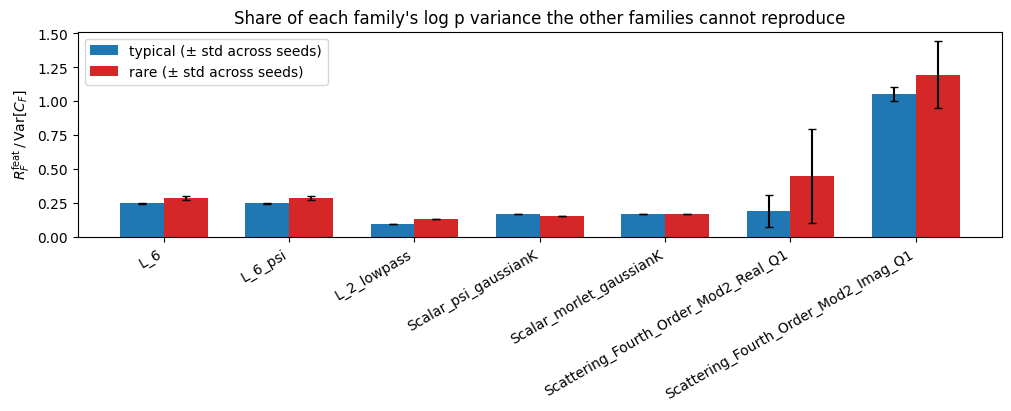

typical: lowest R_feat/var_raw (most replaceable) = L_2_lowpass (0.0947); highest (least replaceable) = Scattering_Fourth_Order_Mod2_Imag_Q1 (1.06)
rare: lowest R_feat/var_raw (most replaceable) = L_2_lowpass (0.133); highest (least replaceable) = Scattering_Fourth_Order_Mod2_Imag_Q1 (1.2)

Rare set: Var[C_F + C_G] / (Var[C_F] + Var[C_G])


,L_6,L_6_psi,L_2_lowpass,Scalar_psi_gaussianK,Scalar_morlet_gaussianK,Scattering_Fourth_Order_Mod2_Real_Q1,Scattering_Fourth_Order_Mod2_Imag_Q1
L_6,NaN,0.000257,1.04,0.845,1.16,0.98,1
L_6_psi,0.000257,NaN,0.957,1.15,0.848,1.02,1
L_2_lowpass,1.04,0.957,NaN,0.989,1.01,1,0.996
Scalar_psi_gaussianK,0.845,1.15,0.989,NaN,3.73e-05,1,1
Scalar_morlet_gaussianK,1.16,0.848,1.01,3.73e-05,NaN,1,1
Scattering_Fourth_Order_Mod2_Real_Q1,0.98,1.02,1,1,1,NaN,0.989
Scattering_Fourth_Order_Mod2_Imag_Q1,1,1,0.996,1,1,0.989,NaN


L_6 + Scattering_Fourth_Order_Mod2_Real_Q1: 0.98


In [19]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
xpos = np.arange(len(fam_only))
for i, set_name in enumerate(['typical', 'rare']):
    ratio = np.stack([res[set_name, F]['R_feat/var_raw'] for F in fam_only])   # (n_families, n_seeds)
    ax.bar(xpos + (i - 0.5) * 0.35, ratio.mean(1), 0.35, yerr=ratio.std(1, ddof=1), capsize=3,
           color=category_colors[set_name], label=f'{set_name} (± std across seeds)')
ax.set_xticks(xpos); ax.set_xticklabels(fam_only, rotation=30, ha='right')
ax.set_ylabel(r'$R_F^{\rm feat}\,/\,\mathrm{Var}[C_F]$')
ax.set_title('Share of each family\'s log p variance the other families cannot reproduce')
ax.legend()
plt.show()

for set_name in ['typical', 'rare']:
    r = {F: res[set_name, F]['R_feat/var_raw'].mean() for F in fam_only}
    order = sorted(r, key=r.get)
    print(f"{set_name}: lowest R_feat/var_raw (most replaceable) = {order[0]} ({r[order[0]]:.3g}); "
          f"highest (least replaceable) = {order[-1]} ({r[order[-1]]:.3g})")

# Pair check on the rare set, seed-averaged theta: Var[C_F + C_G] / (Var[C_F] + Var[C_G])
# (= 1 if uncorrelated, << 1 means F and G compensate each other; diagonal left blank).
C_rare = np.stack([C_bar[F][idx_rare] for F in fam_only]).astype(np.float64)
v_rare = C_rare.var(axis=1, ddof=1)
pair_ratio = pd.DataFrame([[np.nan if i == j else (C_rare[i] + C_rare[j]).var(ddof=1) / (v_rare[i] + v_rare[j])
                            for j in range(len(fam_only))] for i in range(len(fam_only))],
                          index=fam_only, columns=fam_only)
print("\nRare set: Var[C_F + C_G] / (Var[C_F] + Var[C_G])")
display(pair_ratio)
print(f"L_6 + {REAL_KEY}: {pair_ratio.loc['L_6', REAL_KEY]:.4g}")

## 6. Model samples

Each seed's final samples (`saved_results/samples/<config>.pt`), with φ from that seed's own fitted potentials and paired with that seed's θ.

In [36]:
sample_path = {}   # seed_key -> path of that seed's samples file
for key in seed_keys:
    p = root / "saved_results" / "samples" / config_by_seed[key]
    p_pt = p.with_name(p.name + ".pt")
    path = p_pt if p_pt.exists() else (p if p.exists() else None)
    if path is not None:
        sample_path[key] = path
print(f"{len(sample_path)}/{len(seed_keys)} seeds have a samples file")
assert sample_path, 'no samples file found: section 6 needs at least one'

model_norm_checked = False
needs_norm = None
C_model = {}   # seed_key -> {family: (n_model,) array}, includes 'TOTAL'
e_model = {}   # seed_key -> (n_model,) extremeness, same lag-1/max|.| definition and units as the split on x1

for key, path in sample_path.items():
    x_final = torch.load(path, map_location='cpu').reshape(-1, 1, M)

    if not model_norm_checked:
        m, s = x_final.mean().item(), x_final.std().item()
        needs_norm = not (abs(m) < 0.05 and abs(s - 1) < 0.05)
        print(f"model samples {tuple(x_final.shape)}: mean={m:.4g} std={s:.4g} -> "
              f"{'applying' if needs_norm else 'skipping'} normalize() (checked on {key} only)")
        model_norm_checked = True

    x_model = normalize(x_final) if needs_norm else x_final   # CPU; same tensor for phi and extremeness
    phi_model = compute_phi_X(potentials_by_seed[key], x_model.to(device)).detach().cpu().double().numpy()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    s_idx = seed_keys.index(key)
    c_this = {F: phi_model[:, a:b] @ reg_all_np[s_idx, a:b] for F, (a, b) in family_ranges.items()}
    c_this['TOTAL'] = sum(c_this.values())
    C_model[key] = c_this

    accel_model = compute_acceleration(x_model)
    e_model[key] = accel_model.abs().amax(dim=tuple(range(1, accel_model.ndim))).numpy()

print(f"Computed model-sample phi/log-p contributions for {len(C_model)} seeds.")

5/5 seeds have a samples file
model samples (8500, 1, 256): mean=0.006343 std=0.9998 -> skipping normalize() (checked on seed900 only)
Computed model-sample phi/log-p contributions for 5 seeds.


### 6a. Data vs model: TOTAL log p contribution and per-family std

Same-seed theta on data (from section 1's `C`) vs on that seed's model samples, pooled across seeds.

L_6                                           data std= 1.825e+05   model std= 1.714e+05
L_6_psi                                       data std= 1.824e+05   model std= 1.713e+05
L_2_lowpass                                   data std=     135.7   model std=       136
Scalar_psi_gaussianK                          data std=      8452   model std=      8552
Scalar_morlet_gaussianK                       data std=      8323   model std=      8424
Scattering_Fourth_Order_Mod2_Real_Q1          data std=     480.5   model std=     409.8
Scattering_Fourth_Order_Mod2_Imag_Q1          data std=     363.4   model std=     211.7


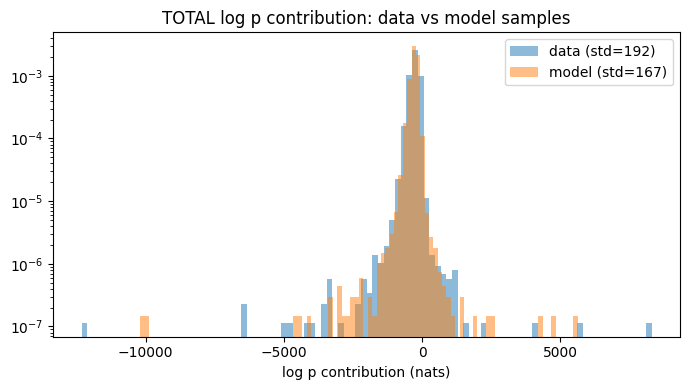

TOTAL mean: data = -271.6, model = -276.9 (each seed's own theta, pooled over 5 seeds)


In [37]:
model_keys = list(C_model.keys())
for F in family_names_all:
    data_vals = np.concatenate([C[F][seed_keys.index(k)] for k in model_keys])
    model_vals = np.concatenate([C_model[k][F] for k in model_keys])
    if F == 'TOTAL':
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(data_vals, bins=100, density=True, alpha=0.5, color='tab:blue',
                label=f'data (std={data_vals.std():.3g})')
        ax.hist(model_vals, bins=100, density=True, alpha=0.5, color='tab:orange',
                label=f'model (std={model_vals.std():.3g})')
        ax.set_yscale('log'); ax.legend()
        ax.set_xlabel('log p contribution (nats)')
        ax.set_title('TOTAL log p contribution: data vs model samples')
        fig.tight_layout(); plt.show()
        print(f"TOTAL mean: data = {data_vals.mean():.4g}, model = {model_vals.mean():.4g} "
              f"(each seed's own theta, pooled over {len(model_keys)} seeds)")
    else:
        print(f"{F:45s} data std={data_vals.std():10.4g}   model std={model_vals.std():10.4g}")

**Caveat.** The MGD samples are not guaranteed to be samples of $p_{\Theta_{\rm reg}}$: $\Theta_{\rm reg}$ is a separate regularised fit (and depends on `LAM`), not the $\theta$ that drove the sampler. A gap between the data and model TOTAL means above is read with that in mind.

### 6b. Rare fraction: model vs data, same cutoff

Apply the data cutoff `cutoff_p95` (from the split on `x1`) to the model samples' max |lag-1 increment|, computed in the same normalized units.

In [38]:
data_rare_frac = len(idx_rare) / n1
_, _, info99 = extract_rare_typical(x1, criterion='percentile', percentile=99)
cutoff_p99 = info99['cutoff']

print("CAVEAT: cutoffs and both extremeness values are in x1's normalized units; model samples are taken to "
      "already be in those units (mean/std checked on one seed, in the loading cell above).")
rows = []
for name, cut, data_frac in (('p95', cutoff_p95, data_rare_frac), ('p99', cutoff_p99, (e > cutoff_p99).mean())):
    per_seed = np.array([(e_model[k] > cut).mean() for k in C_model])
    pooled = np.concatenate([e_model[k] for k in C_model])
    rows.append({'data cutoff': name, 'cutoff (x1 units)': cut, 'data fraction': data_frac,
                 'model fraction (pooled)': (pooled > cut).mean(),
                 'model n above (pooled)': int((pooled > cut).sum()), 'model n (pooled)': len(pooled),
                 'model fraction, std across seeds': per_seed.std(ddof=1) if len(per_seed) > 1 else np.nan})
display(pd.DataFrame(rows))

CAVEAT: cutoffs and both extremeness values are in x1's normalized units; model samples are taken to already be in those units (mean/std checked on one seed, in the loading cell above).


,data cutoff,cutoff (x1 units),data fraction,model fraction (pooled),model n above (pooled),model n (pooled),"model fraction, std across seeds"
0,p95,0.313,0.05,0.0276,1175,42500,0.00145
1,p99,0.553,0.01,0.00704,299,42500,0.000337
